# Clasificación de papas nativas - Swin-Tiny con dataset combinado experimental

Notebook experimental para entrenar y evaluar usando el dataset combinado completo mediante una división 70/15/15. Este archivo mezcla todas las imágenes disponibles dentro del flujo de entrenamiento y evaluación, pero conserva trazabilidad interna del origen para evitar errores metodológicos y revisar fugas de datos.

Para una tesis o publicación, no se debe presentar contenido generado/aumentado como si fuera captura real original; este notebook queda como experimento complementario al protocolo principal.

Los artefactos se guardan en `OUTPUT_DIR`: distribución del split, auditorías, métricas globales, métricas por origen, matrices de confusión, modelo entrenado y exportación ONNX.

In [1]:
# Dependencias ligeras. No se actualizan pandas/matplotlib para evitar conflictos en Kaggle.
!pip -q install timm torchinfo seaborn scikit-learn

In [2]:
# Imports de PyTorch, timm, métricas y visualización
import os
import math
import random
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
print("Dispositivo:", device)
print("GPUs:", GPU_COUNT)
for i in range(GPU_COUNT):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name} - VRAM {props.total_memory / 1024**3:.1f} GB")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

PyTorch: 2.10.0+cu128
timm: 1.0.25
Dispositivo: cuda
GPUs: 2
  GPU 0: Tesla T4 - VRAM 14.6 GB
  GPU 1: Tesla T4 - VRAM 14.6 GB


In [3]:
# Configuración Kaggle, dataset aumentado y manifest anti-fuga
import os, re, json, random, shutil, zipfile, hashlib, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

TAG = "swin_dataset_combinado"
FAST_KAGGLE_RUN = True
SAVE_MODEL_PLOTS = True
EXPORT_ONNX = False
RUN_STRICT_NEAR_DUP_AUDIT = False

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}
MANIFEST_FILENAME = "split_manifest_70_15_15_visual_clusters_v2.csv"
# Protocolo de división para tesis y experimentación.
# thesis_real_eval: sintéticas solo en train; val/test quedan reales.
# mixed_synthetic_eval: redivide reales+sintéticas en train/val/test para experimento complementario.
SPLIT_PROTOCOL = "mixed_synthetic_eval"
VALID_SPLIT_PROTOCOLS = {"thesis_real_eval", "mixed_synthetic_eval"}
if SPLIT_PROTOCOL not in VALID_SPLIT_PROTOCOLS:
    raise ValueError(f"SPLIT_PROTOCOL debe ser uno de {sorted(VALID_SPLIT_PROTOCOLS)}")
MIXED_SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}
SYNTHETIC_MARKERS = ("__sd_img2img_synthetic_1000",)
KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")
IS_KAGGLE = KAGGLE_INPUT_DIR.exists() and KAGGLE_WORKING_DIR.exists()

if IS_KAGGLE:
    WORK_ROOT = KAGGLE_WORKING_DIR / "tomas_training"
    EXTRACT_ROOT = KAGGLE_WORKING_DIR / "tomas_extracted"
else:
    WORK_ROOT = Path.cwd() / "tomas_training_local"
    EXTRACT_ROOT = Path.cwd()

OUTPUT_DIR = WORK_ROOT / f"outputs_{TAG}"
MODEL_DIR = OUTPUT_DIR / "models"
for p in [WORK_ROOT, OUTPUT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)


def count_images(root):
    root = Path(root)
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)


def extract_tomas_zip_if_needed():
    if not IS_KAGGLE:
        return [Path.cwd()]
    zip_candidates = sorted(KAGGLE_INPUT_DIR.rglob("tomas.zip"))
    if not zip_candidates:
        return [KAGGLE_INPUT_DIR]
    zip_path = zip_candidates[0]
    marker = EXTRACT_ROOT / ".extract_done"
    if not marker.exists() or marker.read_text(encoding="utf-8") != str(zip_path):
        if EXTRACT_ROOT.exists():
            shutil.rmtree(EXTRACT_ROOT)
        EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        print(f"Extrayendo {zip_path} en {EXTRACT_ROOT} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(EXTRACT_ROOT)
        marker.write_text(str(zip_path), encoding="utf-8")
    return [EXTRACT_ROOT, KAGGLE_INPUT_DIR]


# Rutas preferidas según tu dataset actual en Kaggle.
# Kaggle puede mostrar el nombre como DATASET_VARIEDADES, pero el path real puede variar en mayúsculas/minúsculas.
KAGGLE_TOMAS_ROOT_HINTS = [
    Path("/kaggle/input/DATASET_VARIEDADES/tomas"),
    Path("/kaggle/input/dataset-variedades/tomas"),
    Path("/kaggle/input/dataset_variedades/tomas"),
]


def find_tomas_roots(search_roots):
    candidates = []
    for hint in KAGGLE_TOMAS_ROOT_HINTS:
        if (hint / "dataset").exists() and count_images(hint / "dataset") > 0:
            candidates.append(hint)
    for search_root in search_roots:
        for dataset_dir in Path(search_root).rglob("dataset"):
            if dataset_dir.is_dir() and count_images(dataset_dir) > 0:
                candidates.append(dataset_dir.parent)
    unique = []
    seen = set()
    for candidate in candidates:
        key = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if key not in seen:
            seen.add(key)
            unique.append(candidate)
    return unique


def find_dataset_and_manifest():
    roots = extract_tomas_zip_if_needed()
    tomas_roots = find_tomas_roots(roots)
    if not tomas_roots:
        raise FileNotFoundError("No se encontró una estructura tomas/dataset dentro de tomas.zip o /kaggle/input.")

    scored_roots = []
    for tomas_root in tomas_roots:
        dataset_dir = tomas_root / "dataset"
        n_images = count_images(dataset_dir)
        score = n_images
        if tomas_root.name.lower() == "tomas":
            score += 100000
        if "DATASET_VARIEDADES" in str(tomas_root) or "dataset-variedades" in str(tomas_root).lower():
            score += 50000
        scored_roots.append((score, tomas_root, dataset_dir))
    scored_roots = sorted(scored_roots, key=lambda item: item[0], reverse=True)
    _, tomas_root, dataset_dir = scored_roots[0]

    preferred_manifest = tomas_root / MANIFEST_FILENAME
    if preferred_manifest.exists():
        manifest_path = preferred_manifest
    else:
        manifest_candidates = list(tomas_root.rglob(MANIFEST_FILENAME))
        if not manifest_candidates:
            for search_root in roots:
                manifest_candidates.extend(Path(search_root).rglob(MANIFEST_FILENAME))
        manifest_path = sorted(manifest_candidates, key=lambda p: ("backup" in p.name.lower(), len(str(p))))[0] if manifest_candidates else None

    print("Raíz tomas seleccionada:", tomas_root)
    print("Candidatos tomas detectados:")
    for _, candidate_root, candidate_dataset in scored_roots[:5]:
        print(" -", candidate_root, "| imágenes:", count_images(candidate_dataset))
    return dataset_dir, manifest_path

DATASET_DIR, FOUND_MANIFEST_PATH = find_dataset_and_manifest()
SPLIT_MANIFEST_PATH = WORK_ROOT / MANIFEST_FILENAME
if FOUND_MANIFEST_PATH and not SPLIT_MANIFEST_PATH.exists():
    shutil.copy2(FOUND_MANIFEST_PATH, SPLIT_MANIFEST_PATH)
elif FOUND_MANIFEST_PATH and FOUND_MANIFEST_PATH != SPLIT_MANIFEST_PATH:
    shutil.copy2(FOUND_MANIFEST_PATH, SPLIT_MANIFEST_PATH)

print("Entorno:", "Kaggle" if IS_KAGGLE else "Local")
print("DATASET_DIR:", DATASET_DIR)
print("Manifest fuente:", FOUND_MANIFEST_PATH)
print("Manifest editable:", SPLIT_MANIFEST_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Imágenes detectadas:", count_images(DATASET_DIR))


def normalize_key(text):
    text = unicodedata.normalize("NFKD", str(text))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^A-Z0-9]+", "", text.upper())


def rel_after_dataset(path_value):
    parts = Path(str(path_value)).parts
    if "dataset" in parts:
        idx = parts.index("dataset")
        return Path(*parts[idx + 1:]).as_posix()
    return "/".join(parts[-2:])


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def dhash_file(path, hash_size=16):
    resample = getattr(getattr(Image, "Resampling", Image), "LANCZOS")
    with Image.open(path) as img:
        img = img.convert("L").resize((hash_size + 1, hash_size), resample)
        pixels = np.asarray(img, dtype=np.int16)
    diff = pixels[:, 1:] > pixels[:, :-1]
    value = 0
    for bit in diff.flatten():
        value = (value << 1) | int(bit)
    return f"{value:0{(hash_size * hash_size + 3) // 4}x}"


def hamming_hex(a, b):
    return (int(str(a), 16) ^ int(str(b), 16)).bit_count()


def collect_image_index(dataset_dir):
    class_dirs = sorted([p for p in Path(dataset_dir).iterdir() if p.is_dir() and not p.name.startswith(".")], key=lambda p: p.name)
    class_names = [p.name for p in class_dirs]
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    rows = []
    for class_dir in class_dirs:
        for path in sorted(class_dir.rglob("*"), key=lambda p: str(p)):
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
                rows.append({"path": str(path), "class_name": class_dir.name, "label": class_to_idx[class_dir.name]})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No se encontraron imágenes válidas en {dataset_dir}")
    return df, class_names, class_to_idx

all_df, class_names, class_to_idx = collect_image_index(DATASET_DIR)
NUM_CLASSES = len(class_names)
if NUM_CLASSES != 7:
    print(f"Advertencia: se detectaron {NUM_CLASSES} clases, se esperaban 7.")


def is_synthetic_path(path):
    text = str(path).replace("\\", "/")
    return any(marker in text for marker in SYNTHETIC_MARKERS)


def parse_bool_value(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"1", "true", "t", "yes", "y", "si", "sí"}


def stable_text_hash(value, length=16):
    return hashlib.sha1(str(value).encode("utf-8", errors="ignore")).hexdigest()[:length]


all_df["is_synthetic"] = all_df["path"].map(is_synthetic_path)
all_df["source_path"] = np.where(all_df["is_synthetic"], "", all_df["path"])
all_df["source_group_id"] = ""

path_meta = all_df.set_index("path")[["class_name", "label"]].to_dict("index")
all_df["rel_key"] = all_df["path"].map(rel_after_dataset)
all_df["norm_class"] = all_df["class_name"].map(normalize_key)
all_df["file_name"] = all_df["path"].map(lambda p: Path(p).name)
all_df["norm_file"] = all_df["file_name"].map(normalize_key)
rel_map = dict(zip(all_df["rel_key"], all_df["path"]))
class_file_map = dict(zip(zip(all_df["norm_class"], all_df["file_name"]), all_df["path"]))
class_normfile_map = dict(zip(zip(all_df["norm_class"], all_df["norm_file"]), all_df["path"]))


def remap_manifest_row(row):
    original = str(row["path"])
    if Path(original).exists():
        return original
    rel = rel_after_dataset(original)
    if rel in rel_map:
        return rel_map[rel]
    class_key = normalize_key(row.get("class_name", ""))
    file_name = Path(original).name
    if (class_key, file_name) in class_file_map:
        return class_file_map[(class_key, file_name)]
    norm_file = normalize_key(file_name)
    if (class_key, norm_file) in class_normfile_map:
        return class_normfile_map[(class_key, norm_file)]
    return str(DATASET_DIR / rel)


def build_fallback_manifest():
    print("No se encontró manifest válido. Se creará split base: reales 70/15/15 y sintéticas a train.")
    rows = []
    for class_name, class_df in all_df.groupby("class_name", sort=True):
        class_df = class_df.copy().sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        synthetic_mask = class_df["path"].map(is_synthetic_path)
        real_df = class_df[~synthetic_mask].copy().reset_index(drop=True)
        synth_df = class_df[synthetic_mask].copy().reset_index(drop=True)
        n = len(real_df)
        n_train = int(round(n * 0.70))
        n_val = int(round(n * 0.15))
        real_df["split"] = "test"
        real_df.loc[: n_train - 1, "split"] = "train"
        real_df.loc[n_train : n_train + n_val - 1, "split"] = "val"
        synth_df["split"] = "train"
        rows.append(pd.concat([real_df, synth_df], ignore_index=True))
    manifest = pd.concat(rows, ignore_index=True)
    manifest["is_synthetic"] = manifest["path"].map(is_synthetic_path)
    manifest["source_path"] = np.where(manifest["is_synthetic"], "", manifest["path"])
    manifest["source_group_id"] = ""
    manifest["sha256"] = [sha256_file(p) for p in manifest["path"]]
    manifest["visual_hash"] = [dhash_file(p) for p in manifest["path"]]
    manifest["group_id"] = manifest["class_name"] + "__" + manifest["split"] + "__" + np.arange(len(manifest)).astype(str)
    return manifest

if SPLIT_MANIFEST_PATH.exists():
    manifest_df = pd.read_csv(SPLIT_MANIFEST_PATH)
else:
    manifest_df = build_fallback_manifest()

manifest_df["original_path"] = manifest_df["path"].astype(str)
manifest_df["path"] = manifest_df.apply(remap_manifest_row, axis=1)
manifest_df["path_exists"] = manifest_df["path"].map(lambda p: Path(p).exists())
missing_paths = manifest_df[~manifest_df["path_exists"]]
if not missing_paths.empty:
    missing_report = OUTPUT_DIR / "manifest_paths_no_encontrados.csv"
    missing_paths.to_csv(missing_report, index=False, encoding="utf-8")
    raise FileNotFoundError(f"Hay rutas del manifest no encontradas. Revisa {missing_report}")

manifest_df["class_name_original"] = manifest_df.get("class_name", "")
manifest_df["label_original"] = manifest_df.get("label", -1)
manifest_df["class_name"] = manifest_df["path"].map(lambda p: path_meta[p]["class_name"])
manifest_df["label"] = manifest_df["path"].map(lambda p: path_meta[p]["label"])

# Agrega imágenes que estén en el dataset pero no en el manifest; por defecto quedan en train.
manifest_paths = set(manifest_df["path"])
extra_df = all_df[~all_df["path"].isin(manifest_paths)].copy()
if not extra_df.empty:
    print(f"Agregando {len(extra_df)} imágenes ausentes del manifest como train.")
    extra_df["split"] = "train"
    extra_df["original_path"] = extra_df["path"]
    extra_df["class_name_original"] = extra_df["class_name"]
    extra_df["label_original"] = extra_df["label"]
    extra_df["sha256"] = [sha256_file(p) for p in extra_df["path"]]
    extra_df["visual_hash"] = [dhash_file(p) for p in extra_df["path"]]
    extra_df["group_id"] = extra_df["class_name"] + "__extra_train__" + np.arange(len(extra_df)).astype(str)
    extra_df["is_synthetic"] = extra_df["path"].map(is_synthetic_path)
    extra_df["source_path"] = np.where(extra_df["is_synthetic"], "", extra_df["path"])
    extra_df["source_group_id"] = ""
    manifest_df = pd.concat([manifest_df, extra_df], ignore_index=True, sort=False)

for col in ["sha256", "visual_hash", "group_id", "source_path", "source_group_id"]:
    if col not in manifest_df.columns:
        manifest_df[col] = ""

manifest_df["path"] = manifest_df["path"].astype(str)
manifest_df["is_synthetic_path"] = manifest_df["path"].map(is_synthetic_path)
if "is_synthetic" in manifest_df.columns:
    manifest_df["is_synthetic"] = manifest_df["is_synthetic"].map(parse_bool_value) | manifest_df["is_synthetic_path"]
else:
    manifest_df["is_synthetic"] = manifest_df["is_synthetic_path"]
manifest_df["source_path"] = manifest_df["source_path"].fillna("").astype(str)
manifest_df["source_group_id"] = manifest_df["source_group_id"].fillna("").astype(str)


def remap_source_path_value(row):
    value = str(row.get("source_path", "")).strip()
    if not value:
        return ""
    if Path(value).exists():
        return value
    candidate = remap_manifest_row({"path": value, "class_name": row.get("class_name", "")})
    return candidate if Path(candidate).exists() else value


manifest_df["source_path"] = manifest_df.apply(remap_source_path_value, axis=1)
real_missing_source = (~manifest_df["is_synthetic"]) & manifest_df["source_path"].str.strip().eq("")
manifest_df.loc[real_missing_source, "source_path"] = manifest_df.loc[real_missing_source, "path"]
real_missing_source_group = (~manifest_df["is_synthetic"]) & manifest_df["source_group_id"].str.strip().eq("")
manifest_df.loc[real_missing_source_group, "source_group_id"] = manifest_df.loc[real_missing_source_group, "group_id"].astype(str)

source_path_to_group = manifest_df.loc[~manifest_df["is_synthetic"]].drop_duplicates("path").set_index("path")["group_id"].to_dict()
synth_known_source = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().eq("") & manifest_df["source_path"].isin(source_path_to_group)
manifest_df.loc[synth_known_source, "source_group_id"] = manifest_df.loc[synth_known_source, "source_path"].map(source_path_to_group).astype(str)

synth_with_source_group = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().ne("")
manifest_df.loc[synth_with_source_group, "group_id"] = manifest_df.loc[synth_with_source_group, "source_group_id"].astype(str)
synth_with_source_path = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().eq("") & manifest_df["source_path"].str.strip().ne("")
manifest_df.loc[synth_with_source_path, "group_id"] = manifest_df.loc[synth_with_source_path].apply(
    lambda row: f"{row['class_name']}__source_path__{stable_text_hash(row['source_path'])}", axis=1
)

empty_sha = manifest_df["sha256"].isna() | (manifest_df["sha256"].astype(str) == "")
empty_vh = manifest_df["visual_hash"].isna() | (manifest_df["visual_hash"].astype(str) == "")
empty_group = manifest_df["group_id"].isna() | (manifest_df["group_id"].astype(str) == "")
if empty_sha.any():
    manifest_df.loc[empty_sha, "sha256"] = [sha256_file(p) for p in manifest_df.loc[empty_sha, "path"]]
if empty_vh.any():
    manifest_df.loc[empty_vh, "visual_hash"] = [dhash_file(p) for p in manifest_df.loc[empty_vh, "path"]]
if empty_group.any():
    manifest_df.loc[empty_group, "group_id"] = manifest_df.loc[empty_group, "class_name"] + "__generated_group__" + manifest_df.loc[empty_group].index.astype(str)

if "split_original" not in manifest_df.columns:
    manifest_df["split_original"] = manifest_df.get("split", "train")
manifest_df["split_original"] = manifest_df["split_original"].fillna("train").astype(str).str.lower()
manifest_df.loc[~manifest_df["split_original"].isin(["train", "val", "test"]), "split_original"] = "train"


def make_split_group_key(row):
    if bool(row["is_synthetic"]):
        if str(row.get("source_group_id", "")).strip():
            key = f"group__{row['source_group_id']}"
        elif str(row.get("source_path", "")).strip():
            key = f"source_path__{stable_text_hash(row['source_path'])}"
        else:
            key = f"synthetic__{row['group_id']}"
    else:
        key = f"group__{row['group_id']}"
    return f"{row['class_name']}__{key}"


def apply_thesis_real_eval_split(df):
    result = df.copy()
    result["split"] = result["split_original"]
    result.loc[result["is_synthetic"], "split"] = "train"
    return result


def target_split_counts(n, ratios):
    n_train = int(round(n * ratios["train"]))
    n_val = int(round(n * ratios["val"]))
    n_test = max(0, n - n_train - n_val)
    return {"train": n_train, "val": n_val, "test": n_test}


def apply_mixed_synthetic_eval_split(df):
    result_parts = []
    for class_name, class_df in df.groupby("class_name", sort=True):
        class_df = class_df.copy()
        targets = target_split_counts(len(class_df), MIXED_SPLIT_RATIOS)
        groups = class_df.groupby("split_group_key", sort=False).size().reset_index(name="n")
        groups = groups.sample(frac=1.0, random_state=SEED + int(class_df["label"].iloc[0])).reset_index(drop=True)
        counts = {"train": 0, "val": 0, "test": 0}
        assignments = {}
        for _, group_row in groups.iterrows():
            group_size = int(group_row["n"])
            def score(split_name):
                target = max(targets[split_name], 1)
                return (targets[split_name] - counts[split_name]) / target
            selected_split = max(["train", "val", "test"], key=score)
            assignments[group_row["split_group_key"]] = selected_split
            counts[selected_split] += group_size
        class_df["split"] = class_df["split_group_key"].map(assignments)
        print(f"Split mixto {class_name}: objetivo={targets}, obtenido={counts}")
        result_parts.append(class_df)
    return pd.concat(result_parts, ignore_index=True)


manifest_df["split_group_key"] = manifest_df.apply(make_split_group_key, axis=1)
if SPLIT_PROTOCOL == "thesis_real_eval":
    manifest_df = apply_thesis_real_eval_split(manifest_df)
elif SPLIT_PROTOCOL == "mixed_synthetic_eval":
    manifest_df = apply_mixed_synthetic_eval_split(manifest_df)
else:
    raise ValueError(f"SPLIT_PROTOCOL no soportado: {SPLIT_PROTOCOL}")

manifest_df = manifest_df.drop(columns=["path_exists", "is_synthetic_path"], errors="ignore")
manifest_df.to_csv(SPLIT_MANIFEST_PATH, index=False, encoding="utf-8")
manifest_df.to_csv(OUTPUT_DIR / f"split_manifest_{TAG}_kaggle_remapeado.csv", index=False, encoding="utf-8")
manifest_df.to_csv(OUTPUT_DIR / f"split_manifest_{TAG}_{SPLIT_PROTOCOL}.csv", index=False, encoding="utf-8")

train_df = manifest_df[manifest_df["split"] == "train"].sort_values("path").reset_index(drop=True)
val_df = manifest_df[manifest_df["split"] == "val"].sort_values("path").reset_index(drop=True)
test_df = manifest_df[manifest_df["split"] == "test"].sort_values("path").reset_index(drop=True)

origin_split_report = manifest_df.assign(origin=np.where(manifest_df["is_synthetic"], "synthetic", "real"))
reporte_split_protocol = origin_split_report.groupby(["class_name", "split", "origin"], observed=True).size().reset_index(name="n_images")
reporte_split_protocol.to_csv(OUTPUT_DIR / "reporte_split_protocol.csv", index=False, encoding="utf-8")
conteo_real_sintetico_por_split = origin_split_report.pivot_table(
    index="class_name", columns=["split", "origin"], values="path", aggfunc="count", fill_value=0
)
conteo_real_sintetico_por_split.to_csv(OUTPUT_DIR / "conteo_real_sintetico_por_split.csv", encoding="utf-8")
split_protocol_config = {
    "split_protocol": SPLIT_PROTOCOL,
    "description": "thesis_real_eval mantiene val/test reales; mixed_synthetic_eval mezcla reales y sintéticas como experimento complementario.",
    "mixed_split_ratios": MIXED_SPLIT_RATIOS,
    "synthetic_markers": list(SYNTHETIC_MARKERS),
    "n_total": int(len(manifest_df)),
    "n_train": int(len(train_df)),
    "n_val": int(len(val_df)),
    "n_test": int(len(test_df)),
    "n_synthetic_train": int(train_df["is_synthetic"].sum()),
    "n_synthetic_val": int(val_df["is_synthetic"].sum()),
    "n_synthetic_test": int(test_df["is_synthetic"].sum()),
}
(OUTPUT_DIR / "split_protocol_config.json").write_text(json.dumps(split_protocol_config, ensure_ascii=False, indent=2), encoding="utf-8")

distribution_df = pd.concat([
    train_df.assign(split_name="train"),
    val_df.assign(split_name="val"),
    test_df.assign(split_name="test"),
]).pivot_table(index="class_name", columns="split_name", values="path", aggfunc="count", fill_value=0)

(OUTPUT_DIR / "classes.txt").write_text("\n".join(class_names) + "\n", encoding="utf-8")
distribution_df.to_csv(OUTPUT_DIR / f"distribucion_splits_{TAG}.csv", encoding="utf-8")

print(f"Clases ({NUM_CLASSES}):")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")
print(f"Tamaños: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
display(distribution_df)

Raíz tomas seleccionada: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas
Candidatos tomas detectados:
 - /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas | imágenes: 7000
Entorno: Kaggle
DATASET_DIR: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas/dataset
Manifest fuente: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas/split_manifest_70_15_15_visual_clusters_v2.csv
Manifest editable: /kaggle/working/tomas_training/split_manifest_70_15_15_visual_clusters_v2.csv
OUTPUT_DIR: /kaggle/working/tomas_training/outputs_swin_dataset_combinado
Imágenes detectadas: 7000
Split mixto 1 VARIEDAD - PUKA_ÑATA: objetivo={'train': 700, 'val': 150, 'test': 150}, obtenido={'train': 698, 'val': 151, 'test': 151}
Split mixto 2 VARIDAD - TOROPA_WAQRAN: objetivo={'train': 700, 'val': 150, 'test': 150}, obtenido={'train': 699, 'val': 151, 'test': 150}
Split mixto 3 VARIEDAD - PUMAPA_MAKIN: objetivo={'train': 700, 'val': 150, 'test': 150}, obteni

split_name,test,train,val
class_name,,,
1 VARIEDAD - PUKA_ÑATA,151,698,151
2 VARIDAD - TOROPA_WAQRAN,150,699,151
3 VARIEDAD - PUMAPA_MAKIN,150,698,152
4 VARIDAD - PUTISA,150,699,151
5 VARIEDAD - YURAQ_LEGUAS,150,700,150
6 VARIEDAD - YURAQ_JEWICHO,150,698,152
7 VARIEDAD - CANUTILLO,146,682,172


## Vista previa científica del dataset

Esta sección documenta el estado real del dataset antes de entrenar: distribución por clase, distribución por split, proporción de imágenes reales/sintéticas, tamaños de imagen y muestras visuales. Estos artefactos se guardan en `OUTPUT_DIR` para usarlos en la tesis y para verificar que el entrenamiento se realiza con datos correctamente organizados.

Resumen general del dataset


,num_classes,total_images_manifest,train_images,val_images,test_images,real_images,synthetic_images,all_paths_exist
0,7,7000,4874,1079,1047,2800,4200,True


Distribución por clase, split y origen


,test,train,val,real,synthetic,total
class_name,,,,,,
1 VARIEDAD - PUKA_ÑATA,151,698,151,400,600,2000
2 VARIDAD - TOROPA_WAQRAN,150,699,151,400,600,2000
3 VARIEDAD - PUMAPA_MAKIN,150,698,152,400,600,2000
4 VARIDAD - PUTISA,150,699,151,400,600,2000
5 VARIEDAD - YURAQ_LEGUAS,150,700,150,400,600,2000
6 VARIEDAD - YURAQ_JEWICHO,150,698,152,400,600,2000
7 VARIEDAD - CANUTILLO,146,682,172,400,600,2000


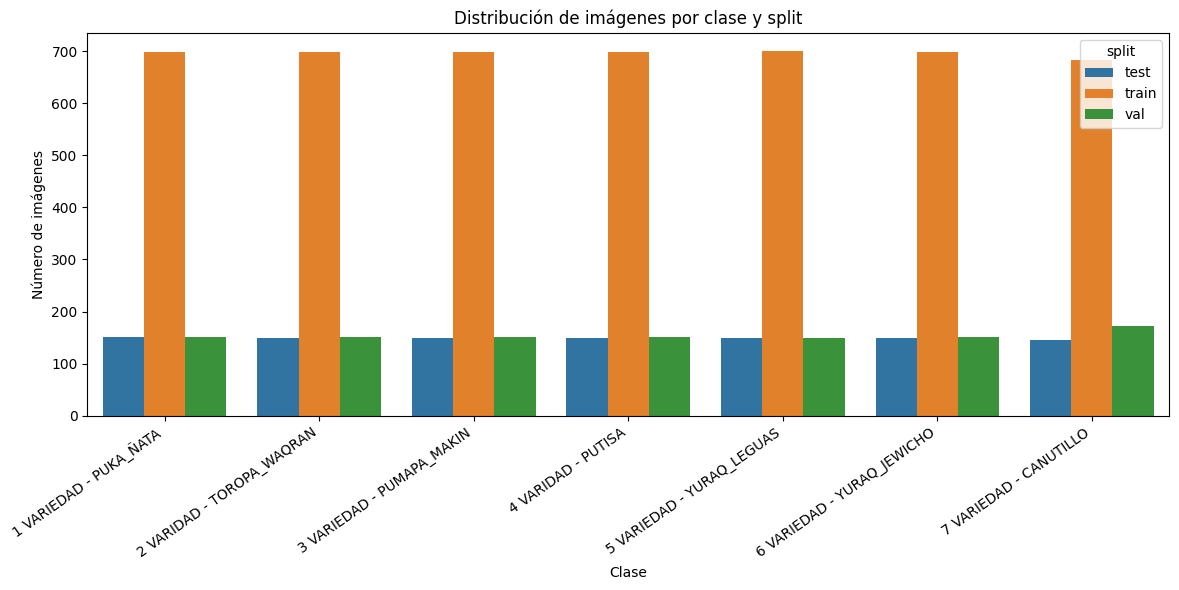

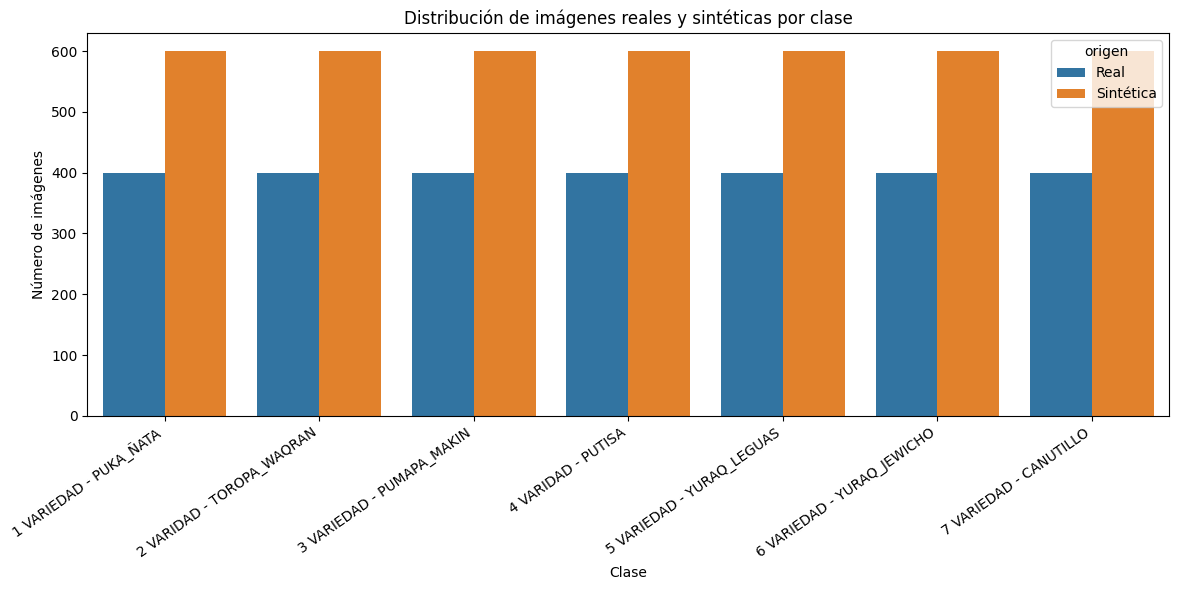

Resumen de tamaños de imagen muestreados


,width,height,aspect_ratio
count,600.000000,600.000000,600.000000
mean,2852.080000,2055.413333,1.199167
std,2563.487773,1583.561254,0.244982
min,768.000000,768.000000,1.000000
25%,768.000000,768.000000,1.000000
50%,768.000000,768.000000,1.000000
75%,6000.000000,4000.000000,1.500000
max,6000.000000,4000.000000,1.500000


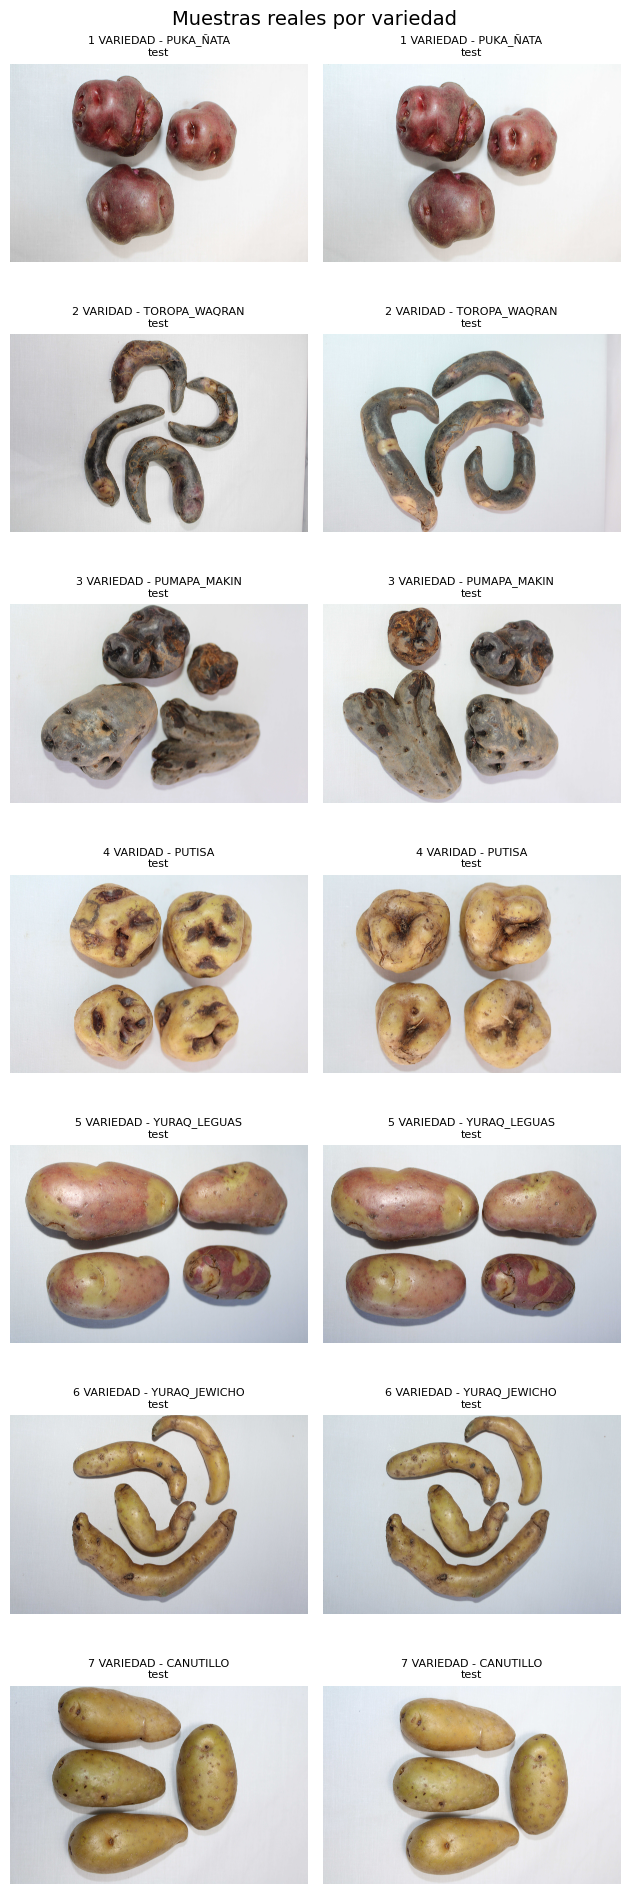

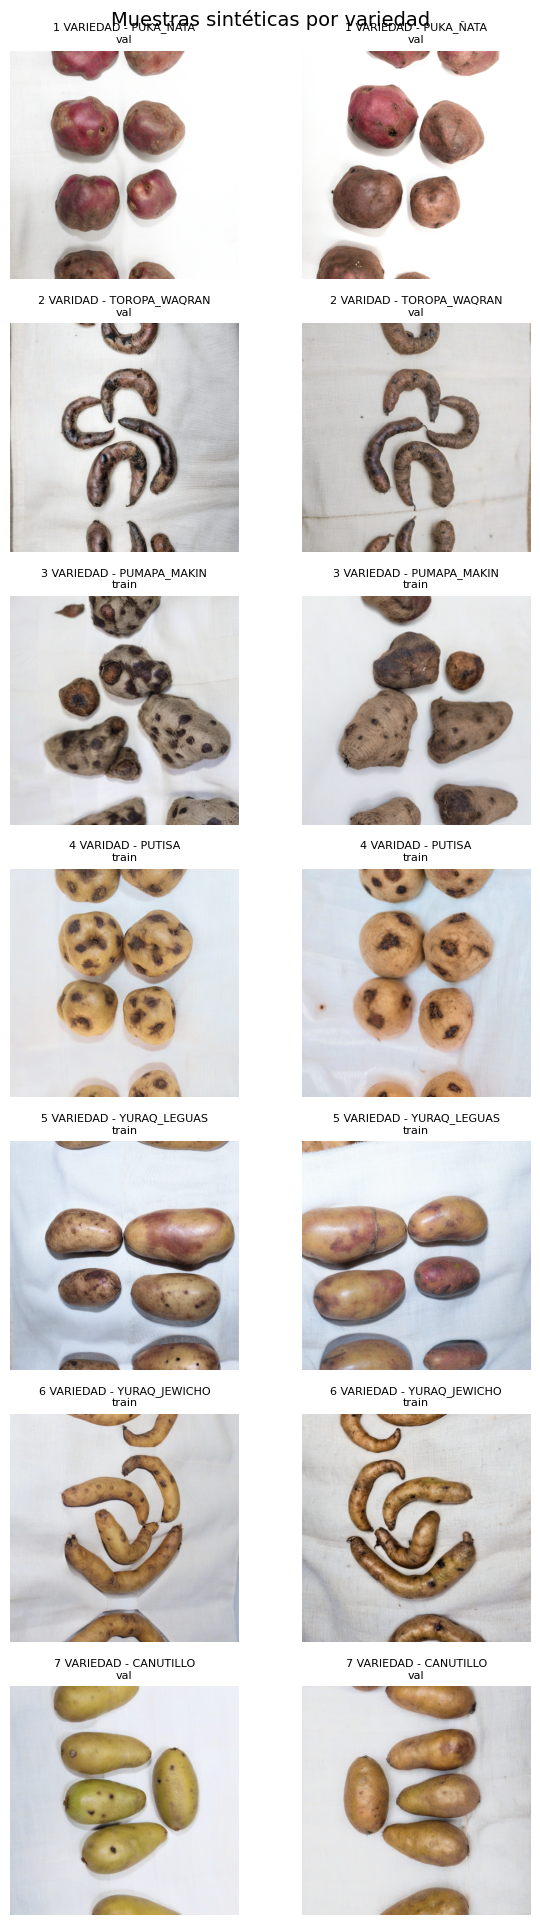

Artefactos de previsualización guardados en: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/previsualizacion_dataset


In [4]:
# Vista previa científica del dataset y control visual de calidad
SYNTHETIC_MARKER = "__sd_img2img_synthetic_1000"
DATA_PREVIEW_DIR = OUTPUT_DIR / "previsualizacion_dataset"
DATA_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

preview_df = manifest_df.copy()
if "is_synthetic" in preview_df.columns:
    preview_df["is_synthetic"] = preview_df["is_synthetic"].map(parse_bool_value)
else:
    preview_df["is_synthetic"] = preview_df["path"].astype(str).str.contains(SYNTHETIC_MARKER, regex=False)
preview_df["origin"] = np.where(preview_df["is_synthetic"], "synthetic", "real")
preview_df["file_name"] = preview_df["path"].map(lambda p: Path(p).name)
preview_df["exists"] = preview_df["path"].map(lambda p: Path(p).exists())

if not preview_df["exists"].all():
    missing_preview_path = DATA_PREVIEW_DIR / "paths_faltantes_previsualizacion.csv"
    preview_df[~preview_df["exists"]].to_csv(missing_preview_path, index=False, encoding="utf-8")
    raise FileNotFoundError(f"Hay rutas inexistentes en el dataset. Revisa {missing_preview_path}")

class_split_table = preview_df.pivot_table(index="class_name", columns="split", values="path", aggfunc="count", fill_value=0)
class_synthetic_table = preview_df.pivot_table(index="class_name", columns="is_synthetic", values="path", aggfunc="count", fill_value=0)
class_synthetic_table = class_synthetic_table.rename(columns={False: "real", True: "synthetic"})
dataset_overview_df = class_split_table.join(class_synthetic_table, how="left").fillna(0).astype(int)
dataset_overview_df["total"] = dataset_overview_df.sum(axis=1)
dataset_overview_df.to_csv(DATA_PREVIEW_DIR / "resumen_dataset_por_clase.csv", encoding="utf-8")

overall_summary_df = pd.DataFrame([{
    "num_classes": NUM_CLASSES,
    "total_images_manifest": len(preview_df),
    "train_images": len(train_df),
    "val_images": len(val_df),
    "test_images": len(test_df),
    "real_images": int((~preview_df["is_synthetic"]).sum()),
    "synthetic_images": int(preview_df["is_synthetic"].sum()),
    "all_paths_exist": bool(preview_df["exists"].all()),
}])
overall_summary_df.to_csv(DATA_PREVIEW_DIR / "resumen_general_dataset.csv", index=False, encoding="utf-8")

print("Resumen general del dataset")
display(overall_summary_df)
print("Distribución por clase, split y origen")
display(dataset_overview_df)

# Gráficos de distribución
plot_df = preview_df.groupby(["class_name", "split"]).size().reset_index(name="count")
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="class_name", y="count", hue="split")
plt.title("Distribución de imágenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DATA_PREVIEW_DIR / "distribucion_clase_split.png", dpi=150, bbox_inches="tight")
plt.show()

origin_df = preview_df.groupby(["class_name", "is_synthetic"]).size().reset_index(name="count")
origin_df["origen"] = np.where(origin_df["is_synthetic"], "Sintética", "Real")
plt.figure(figsize=(12, 6))
sns.barplot(data=origin_df, x="class_name", y="count", hue="origen")
plt.title("Distribución de imágenes reales y sintéticas por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DATA_PREVIEW_DIR / "distribucion_real_sintetica.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadística de tamaños de imagen en una muestra acotada para no demorar Kaggle.
size_sample = preview_df.sample(n=min(len(preview_df), 600), random_state=SEED).copy()
size_rows = []
for _, row in size_sample.iterrows():
    with Image.open(row["path"]) as img:
        width, height = img.size
    size_rows.append({
        "path": row["path"],
        "class_name": row["class_name"],
        "split": row["split"],
        "is_synthetic": bool(row["is_synthetic"]),
        "width": width,
        "height": height,
        "aspect_ratio": width / max(height, 1),
    })
image_size_df = pd.DataFrame(size_rows)
image_size_df.to_csv(DATA_PREVIEW_DIR / "muestra_tamanos_imagenes.csv", index=False, encoding="utf-8")
print("Resumen de tamaños de imagen muestreados")
display(image_size_df[["width", "height", "aspect_ratio"]].describe())

# Muestras visuales reales y sintéticas por clase.
def plot_dataset_samples(sample_df, title, out_name, samples_per_class=2):
    selected = []
    for class_name in class_names:
        part = sample_df[sample_df["class_name"] == class_name].head(samples_per_class)
        selected.extend(part.to_dict("records"))
    if not selected:
        print(f"No hay imágenes para: {title}")
        return
    cols = samples_per_class
    rows = len(class_names)
    plt.figure(figsize=(cols * 3.2, rows * 2.8))
    for i, row in enumerate(selected, 1):
        img = Image.open(row["path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ax.set_title(f"{row['class_name']}\n{row['split']}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(DATA_PREVIEW_DIR / out_name, dpi=150, bbox_inches="tight")
    plt.show()

real_samples_df = preview_df[~preview_df["is_synthetic"]].sort_values(["class_name", "split", "path"])
synthetic_samples_df = preview_df[preview_df["is_synthetic"]].sort_values(["class_name", "path"])
plot_dataset_samples(real_samples_df, "Muestras reales por variedad", "muestras_reales_por_variedad.png", samples_per_class=2)
plot_dataset_samples(synthetic_samples_df, "Muestras sintéticas por variedad", "muestras_sinteticas_por_variedad.png", samples_per_class=2)

print(f"Artefactos de previsualización guardados en: {DATA_PREVIEW_DIR}")

In [5]:
# Auditoría de fugas entre particiones y control del protocolo de split

def cross_split_report(df, column):
    clean_df = df[df[column].notna() & df[column].astype(str).str.strip().ne("")].copy()
    spread = clean_df.groupby(column)["split"].nunique()
    risky_values = spread[spread > 1].index
    return clean_df[clean_df[column].isin(risky_values)].sort_values([column, "split", "path"])

if SPLIT_PROTOCOL == "thesis_real_eval":
    synth_eval = manifest_df[manifest_df["is_synthetic"] & manifest_df["split"].isin(["val", "test"])]
    if not synth_eval.empty:
        path = OUTPUT_DIR / f"sinteticas_en_val_test_{TAG}.csv"
        synth_eval.to_csv(path, index=False, encoding="utf-8")
        raise RuntimeError(f"El protocolo de tesis exige val/test reales. Revisa {path}")

exact_leaks = cross_split_report(manifest_df, "sha256")
group_leaks = cross_split_report(manifest_df, "group_id")

if not exact_leaks.empty:
    path = OUTPUT_DIR / f"fuga_hash_exacta_{TAG}.csv"
    exact_leaks.to_csv(path, index=False, encoding="utf-8")
    raise RuntimeError(f"Fuga exacta detectada. Revisa {path}")

if not group_leaks.empty:
    path = OUTPUT_DIR / f"fuga_group_id_{TAG}.csv"
    group_leaks.to_csv(path, index=False, encoding="utf-8")
    raise RuntimeError(f"Fuga por group_id/source_group_id detectada. Revisa {path}")

if RUN_STRICT_NEAR_DUP_AUDIT:
    near_rows = []
    for class_name, class_df in manifest_df.groupby("class_name", sort=True):
        hashes = class_df[["visual_hash", "split", "path"]].drop_duplicates("visual_hash").to_dict("records")
        for i in range(len(hashes)):
            for j in range(i + 1, len(hashes)):
                if hashes[i]["split"] == hashes[j]["split"]:
                    continue
                distance = hamming_hex(hashes[i]["visual_hash"], hashes[j]["visual_hash"])
                if distance <= 8:
                    near_rows.append({"class_name": class_name, "hamming_distance": distance, "path_a": hashes[i]["path"], "split_a": hashes[i]["split"], "path_b": hashes[j]["path"], "split_b": hashes[j]["split"]})

    near_df = pd.DataFrame(near_rows)
    if not near_df.empty:
        path = OUTPUT_DIR / f"fuga_near_duplicates_{TAG}.csv"
        near_df.to_csv(path, index=False, encoding="utf-8")
        raise RuntimeError(f"Near-duplicates cruzan particiones. Revisa {path}")

print(f"Auditoría OK para SPLIT_PROTOCOL={SPLIT_PROTOCOL}: sin duplicados exactos ni group_id cruzando train/val/test.")


Auditoría OK para SPLIT_PROTOCOL=mixed_synthetic_eval: sin duplicados exactos ni group_id cruzando train/val/test.


In [6]:
# Dataset y DataLoaders optimizados para Kaggle
IMG_SIZE = 224
PER_GPU_BATCH = 32 if FAST_KAGGLE_RUN else 24
BATCH_SIZE = PER_GPU_BATCH * max(GPU_COUNT, 1)
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.82, 1.00), ratio=(0.90, 1.10), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.35),
    transforms.RandomApply([transforms.RandomRotation(20, interpolation=transforms.InterpolationMode.BICUBIC)], p=0.65),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.14, contrast=0.14, saturation=0.12, hue=0.025)], p=0.75),
    transforms.RandomGrayscale(p=0.04),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08), ratio=(0.3, 3.3), value="random"),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImagePathDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df["path"].astype(str).tolist()
        self.labels = df["label"].astype("int64").tolist()
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": PIN_MEMORY}
if NUM_WORKERS > 0:
    loader_kwargs.update({"worker_init_fn": seed_worker, "persistent_workers": True, "prefetch_factor": 2})

train_dataset = ImagePathDataset(train_df, transform=train_transforms)
val_dataset = ImagePathDataset(val_df, transform=eval_transforms)
test_dataset = ImagePathDataset(test_df, transform=eval_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED), **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
print("Batch size global:", BATCH_SIZE, "workers:", NUM_WORKERS)
print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))

Batch size global: 64 workers: 4
Train/Val/Test: 4874 1079 1047


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

DataParallel activo con 2 GPUs


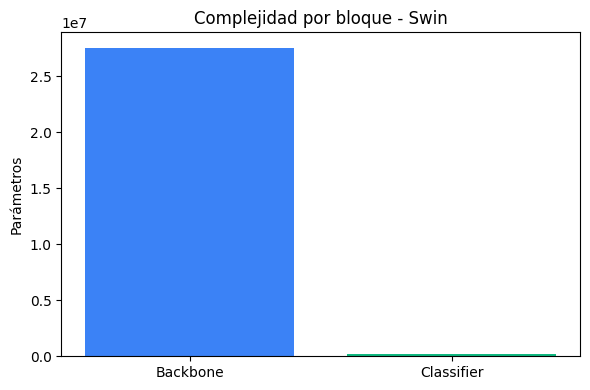

,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,backbone_params,classifier_params,batch_size_global,gpu_count
0,swin_tiny_patch4_window7_224,224,7,27719553,27719553,0,27519354,200199,64,2


In [7]:
# Modelo Swin-Tiny + visualización y complejidad
class SwinTinyClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        try:
            self.backbone = timm.create_model("swin_tiny_patch4_window7_224", pretrained=pretrained, num_classes=0, global_pool="avg")
        except Exception as exc:
            print("No se pudieron cargar pesos pretrained; se inicializa sin pretrained:", exc)
            self.backbone = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=0, global_pool="avg")
        num_features = self.backbone.num_features
        self.classifier = nn.Sequential(nn.LayerNorm(num_features), nn.Dropout(0.30), nn.Linear(num_features, 256), nn.GELU(), nn.Dropout(0.20), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.backbone(x))
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.classifier.parameters():
            p.requires_grad = True
    def unfreeze_last_backbone_fraction(self, fraction=0.25):
        params = list(self.backbone.parameters())
        for p in params:
            p.requires_grad = False
        start = int(len(params) * (1.0 - fraction))
        for p in params[start:]:
            p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True

def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def visualize_model(model, output_dir, name="swin"):
    output_dir = Path(output_dir)
    core = unwrap_model(model)
    (output_dir / f"resumen_modelo_{name}.txt").write_text(str(core), encoding="utf-8")
    total = sum(p.numel() for p in core.parameters())
    trainable = sum(p.numel() for p in core.parameters() if p.requires_grad)
    backbone = sum(p.numel() for p in core.backbone.parameters())
    classifier = sum(p.numel() for p in core.classifier.parameters())
    complexity = pd.DataFrame([{
        "modelo": "swin_tiny_patch4_window7_224",
        "img_size": IMG_SIZE,
        "num_clases": NUM_CLASSES,
        "total_params": int(total),
        "trainable_params": int(trainable),
        "non_trainable_params": int(total - trainable),
        "backbone_params": int(backbone),
        "classifier_params": int(classifier),
        "batch_size_global": BATCH_SIZE,
        "gpu_count": GPU_COUNT,
    }])
    complexity.to_csv(output_dir / f"complejidad_{name}.csv", index=False)
    try:
        from torchinfo import summary
        info = summary(core, input_size=(1, 3, IMG_SIZE, IMG_SIZE), verbose=0, col_names=("input_size", "output_size", "num_params", "trainable"))
        (output_dir / f"torchinfo_{name}.txt").write_text(str(info), encoding="utf-8")
    except Exception as exc:
        print("No se pudo generar torchinfo:", exc)
    plt.figure(figsize=(6, 4))
    plt.bar(["Backbone", "Classifier"], [backbone, classifier], color=["#3B82F6", "#10B981"])
    plt.title("Complejidad por bloque - Swin")
    plt.ylabel("Parámetros")
    plt.tight_layout()
    plt.savefig(output_dir / f"complejidad_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    display(complexity)
    return complexity

model = SwinTinyClassifier(NUM_CLASSES, pretrained=True).to(device)
if GPU_COUNT > 1:
    model = nn.DataParallel(model)
    print("DataParallel activo con", GPU_COUNT, "GPUs")
complexity_swin = visualize_model(model, OUTPUT_DIR, "swin_initial")

In [8]:
# Funciones de entrenamiento, evaluación y optimización
USE_AMP = torch.cuda.is_available()
LABEL_SMOOTHING = 0.08
WEIGHT_DECAY = 0.05
HEAD_LR = 3e-4
BACKBONE_FINE_TUNE_LR = 1e-5
HEAD_FINE_TUNE_LR = 8e-5
WARMUP_EPOCHS = 2 if FAST_KAGGLE_RUN else 5

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def amp_context():
    return torch.amp.autocast(device_type="cuda", enabled=USE_AMP) if USE_AMP else nullcontext()

def get_lr_scheduler(optimizer, epochs):
    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, steps_per_epoch * epochs)
    warmup_steps = max(1, min(total_steps // 3, steps_per_epoch * WARMUP_EPOCHS))
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def build_optimizer(model, phase):
    core = unwrap_model(model)
    if phase == "head":
        core.freeze_backbone()
        params = [p for p in model.parameters() if p.requires_grad]
        return optim.AdamW(params, lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    core.unfreeze_last_backbone_fraction(0.25)
    backbone_params = [p for p in core.backbone.parameters() if p.requires_grad]
    head_params = [p for p in core.classifier.parameters() if p.requires_grad]
    return optim.AdamW([{"params": backbone_params, "lr": BACKBONE_FINE_TUNE_LR}, {"params": head_params, "lr": HEAD_FINE_TUNE_LR}], weight_decay=WEIGHT_DECAY)

def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)
    for inputs, targets in tqdm(loader, desc="Training", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with amp_context():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        bs = targets.size(0)
        running_loss += loss.item() * bs
        correct += outputs.argmax(1).eq(targets).sum().item()
        total += bs
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_probs = [], [], []
    for inputs, targets in tqdm(loader, desc="Evaluating", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with amp_context():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        bs = targets.size(0)
        running_loss += loss.item() * bs
        correct += preds.eq(targets).sum().item()
        total += bs
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_targets), np.array(all_probs)

Epoch 1 (head 1/3)


Training:   0%|          | 0/77 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/17 [00:00<?, ?it/s]

Train loss=1.2330 acc=0.6793 | Val loss=0.5590 acc=0.9592 | LR=3.00e-04
Mejor modelo guardado.
Epoch 2 (head 2/3)


Training:   0%|          | 0/77 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/17 [00:00<?, ?it/s]

Train loss=0.4250 acc=0.9926 | Val loss=0.4037 acc=0.9944 | LR=4.95e-07
Mejor modelo guardado.
Epoch 12 (fine_tune 9/9)


Training:   0%|          | 0/77 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/17 [00:00<?, ?it/s]

Train loss=0.4264 acc=0.9908 | Val loss=0.4036 acc=0.9944 | LR=0.00e+00
Mejor modelo guardado.
Mejor fase Swin: fine_tune epoch: 12 val_loss: 0.40357189530902043


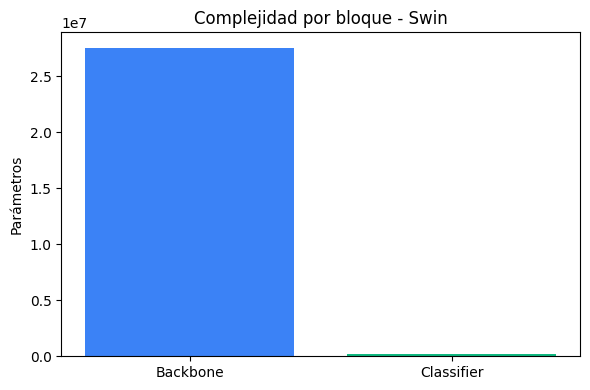

,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,backbone_params,classifier_params,batch_size_global,gpu_count
0,swin_tiny_patch4_window7_224,224,7,27719553,17344419,10375134,27519354,200199,64,2


,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,backbone_params,classifier_params,batch_size_global,gpu_count
0,swin_tiny_patch4_window7_224,224,7,27719553,17344419,10375134,27519354,200199,64,2


In [9]:
# Entrenamiento en dos fases
EPOCHS = 12 if FAST_KAGGLE_RUN else 30
HEAD_EPOCHS = 3 if FAST_KAGGLE_RUN else 8
FINE_TUNE_EPOCHS = max(EPOCHS - HEAD_EPOCHS, 1)
PATIENCE = 3 if FAST_KAGGLE_RUN else 8

best_model_path = MODEL_DIR / "best_model_swin.pt"
final_model_path = MODEL_DIR / "swin_tiny_papas_final.pt"
history = {"epoch": [], "phase": [], "train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": [], "lr": []}
best_val_loss = float("inf")
best_phase = None
best_epoch = 0

def run_phase(phase, epochs, start_epoch):
    global best_val_loss, best_phase, best_epoch
    optimizer = build_optimizer(model, phase)
    scheduler = get_lr_scheduler(optimizer, epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    phase_patience = 0
    for local_epoch in range(1, epochs + 1):
        epoch = start_epoch + local_epoch
        print(f"Epoch {epoch} ({phase} {local_epoch}/{epochs})")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader)
        lr = min(group["lr"] for group in optimizer.param_groups)
        history["epoch"].append(epoch)
        history["phase"].append(phase)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["lr"].append(lr)
        pd.DataFrame(history).to_csv(OUTPUT_DIR / "historial_entrenamiento_swin.csv", index=False, encoding="utf-8")
        print(f"Train loss={train_loss:.4f} acc={train_acc:.4f} | Val loss={val_loss:.4f} acc={val_acc:.4f} | LR={lr:.2e}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_phase = phase
            best_epoch = epoch
            phase_patience = 0
            torch.save({"model_state_dict": unwrap_model(model).state_dict(), "epoch": epoch, "phase": phase, "val_loss": val_loss, "val_acc": val_acc, "class_names": class_names}, best_model_path)
            print("Mejor modelo guardado.")
        else:
            phase_patience += 1
            if phase_patience >= PATIENCE:
                print("Early stopping de fase.")
                break
    return start_epoch + local_epoch

current_epoch = run_phase("head", HEAD_EPOCHS, 0)
current_epoch = run_phase("fine_tune", FINE_TUNE_EPOCHS, current_epoch)

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])
torch.save({"model_state_dict": unwrap_model(model).state_dict(), "class_names": class_names, "best_epoch": best_epoch, "best_phase": best_phase, "best_val_loss": best_val_loss}, final_model_path)
history_df = pd.DataFrame(history)
print("Mejor fase Swin:", best_phase, "epoch:", best_epoch, "val_loss:", best_val_loss)
visualize_model(model, OUTPUT_DIR, "swin_final")

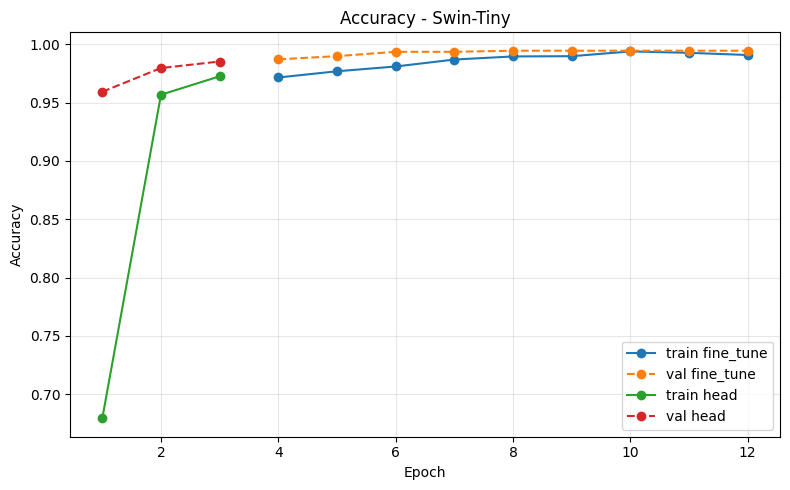

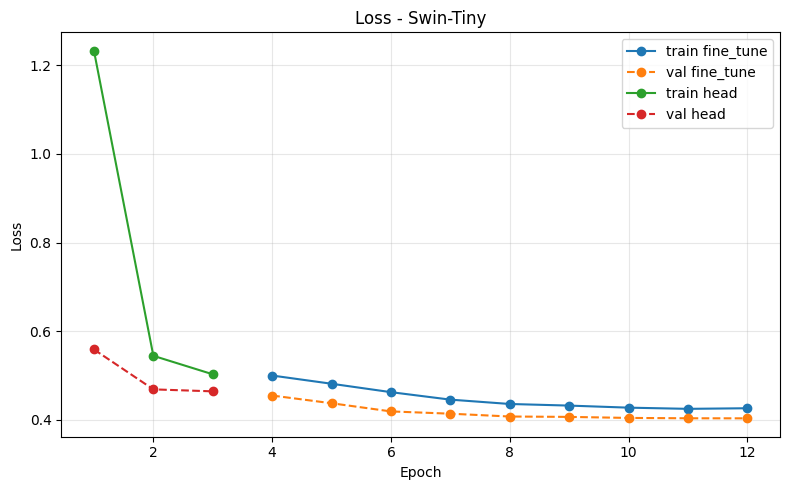

In [10]:
# Curvas de entrenamiento
history_df = pd.read_csv(OUTPUT_DIR / "historial_entrenamiento_swin.csv")

plt.figure(figsize=(8, 5))
for phase, part in history_df.groupby("phase"):
    plt.plot(part["epoch"], part["train_accuracy"], marker="o", label=f"train {phase}")
    plt.plot(part["epoch"], part["val_accuracy"], marker="o", linestyle="--", label=f"val {phase}")
plt.title("Accuracy - Swin-Tiny")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curva_accuracy_swin.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for phase, part in history_df.groupby("phase"):
    plt.plot(part["epoch"], part["train_loss"], marker="o", label=f"train {phase}")
    plt.plot(part["epoch"], part["val_loss"], marker="o", linestyle="--", label=f"val {phase}")
plt.title("Loss - Swin-Tiny")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curva_loss_swin.png", dpi=150, bbox_inches="tight")
plt.show()

Evaluating:   0%|          | 0/17 [00:00<?, ?it/s]

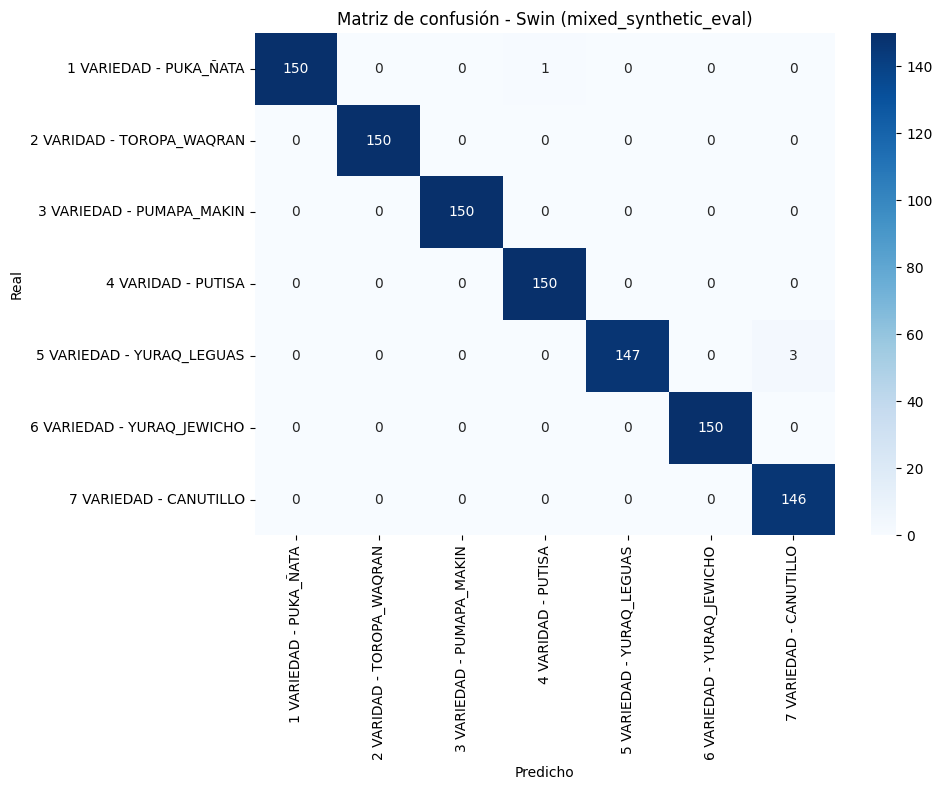

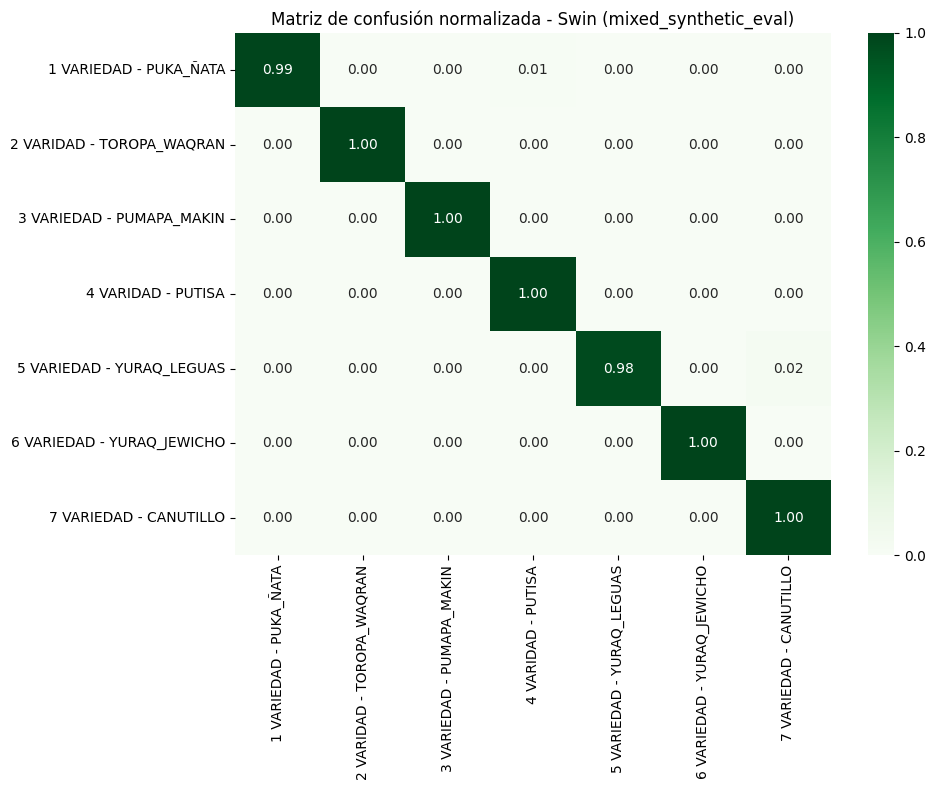

,modelo,split_protocol,split_final,num_clases,n_train,n_val,n_test,n_test_real,n_test_synthetic,best_epoch_by_val_loss,...,test_loss,test_accuracy,test_accuracy_sklearn,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,Swin_Tiny_dataset_combinado_experimental_kaggle,mixed_synthetic_eval,test,7,4874,1079,1047,412,635,12,...,0.402624,0.99618,0.99618,0.996197,0.996178,0.996197,0.996155,0.996244,0.99618,0.99618


,modelo,split_protocol,split_final,eval_subset,num_clases,n_train,n_val,n_test,n_samples,n_real,...,test_loss,test_accuracy_framework,test_accuracy_sklearn,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,Swin_Tiny_dataset_combinado_experimental_kaggle,mixed_synthetic_eval,test,global,7,4874,1079,1047,1047,412,...,0.402624,0.99618,0.996180,0.996197,0.996178,0.996197,0.996155,0.996244,0.996180,0.996180
1,Swin_Tiny_dataset_combinado_experimental_kaggle,mixed_synthetic_eval,test,real_only,7,4874,1079,1047,412,412,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Swin_Tiny_dataset_combinado_experimental_kaggle,mixed_synthetic_eval,test,synthetic_only,7,4874,1079,1047,635,0,...,NaN,NaN,0.993701,0.993405,0.993985,0.993405,0.993605,0.993867,0.993701,0.993696


,precision,recall,f1-score,support
1 VARIEDAD - PUKA_ÑATA,1.000000,0.993377,0.996678,151.00000
2 VARIDAD - TOROPA_WAQRAN,1.000000,1.000000,1.000000,150.00000
3 VARIEDAD - PUMAPA_MAKIN,1.000000,1.000000,1.000000,150.00000
4 VARIDAD - PUTISA,0.993377,1.000000,0.996678,150.00000
5 VARIEDAD - YURAQ_LEGUAS,1.000000,0.980000,0.989899,150.00000
6 VARIEDAD - YURAQ_JEWICHO,1.000000,1.000000,1.000000,150.00000
7 VARIEDAD - CANUTILLO,0.979866,1.000000,0.989831,146.00000
accuracy,0.996180,0.996180,0.996180,0.99618
macro avg,0.996178,0.996197,0.996155,1047.00000
weighted avg,0.996244,0.996180,0.996180,1047.00000


In [11]:
# Evaluación final en test según SPLIT_PROTOCOL

def subset_metric_row(model_name, subset_name, mask, y_true, y_pred, framework_loss=np.nan, framework_acc=np.nan):
    mask = np.asarray(mask, dtype=bool)
    n_samples = int(mask.sum())
    row = {
        "modelo": model_name,
        "split_protocol": SPLIT_PROTOCOL,
        "split_final": "test",
        "eval_subset": subset_name,
        "num_clases": NUM_CLASSES,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        "n_samples": n_samples,
        "n_real": int((test_origin[mask] == "real").sum()) if n_samples else 0,
        "n_synthetic": int((test_origin[mask] == "synthetic").sum()) if n_samples else 0,
        "test_loss": float(framework_loss) if not pd.isna(framework_loss) else np.nan,
        "test_accuracy_framework": float(framework_acc) if not pd.isna(framework_acc) else np.nan,
    }
    if n_samples == 0:
        row.update({
            "test_accuracy_sklearn": np.nan,
            "test_balanced_accuracy": np.nan,
            "test_precision_macro": np.nan,
            "test_recall_macro": np.nan,
            "test_f1_macro": np.nan,
            "test_precision_weighted": np.nan,
            "test_recall_weighted": np.nan,
            "test_f1_weighted": np.nan,
        })
        return row
    yt = y_true[mask]
    yp = y_pred[mask]
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(yt, yp, average="weighted", zero_division=0)
    row.update({
        "test_accuracy_sklearn": float(accuracy_score(yt, yp)),
        "test_balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
    })
    return row


def save_subset_report(prefix, subset_name, mask, y_true, y_pred):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return None
    report = pd.DataFrame(classification_report(
        y_true[mask], y_pred[mask], labels=list(range(NUM_CLASSES)), target_names=class_names,
        output_dict=True, zero_division=0
    )).T
    out_path = OUTPUT_DIR / f"classification_report_{prefix}_{subset_name}.csv"
    report.to_csv(out_path, encoding="utf-8")
    return report

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])
test_loss, test_acc, y_pred, y_true, y_prob = evaluate(model, test_loader)
assert len(y_true) == len(test_df)

test_origin = np.where(test_df["is_synthetic"].map(parse_bool_value).to_numpy(), "synthetic", "real")
test_predictions_df = test_df[["path", "class_name", "label", "split", "is_synthetic", "source_path", "source_group_id", "group_id"]].copy()
test_predictions_df["split_protocol"] = SPLIT_PROTOCOL
test_predictions_df["origin"] = test_origin
test_predictions_df["true_label"] = y_true
test_predictions_df["true_class"] = [class_names[i] for i in y_true]
test_predictions_df["pred_label"] = y_pred
test_predictions_df["pred_class"] = [class_names[i] for i in y_pred]
test_predictions_df["confidence_top1"] = y_prob.max(axis=1)
test_predictions_df["is_correct"] = y_true == y_pred
for rank in range(min(3, NUM_CLASSES)):
    top_idx = np.argsort(y_prob, axis=1)[:, ::-1][:, rank]
    test_predictions_df[f"top{rank + 1}_class"] = [class_names[i] for i in top_idx]
    test_predictions_df[f"top{rank + 1}_prob"] = y_prob[np.arange(len(y_prob)), top_idx]
test_predictions_df.to_csv(OUTPUT_DIR / "predicciones_test_swin.csv", index=False, encoding="utf-8")

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTPUT_DIR / "matriz_confusion_swin.csv", encoding="utf-8")

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - Swin ({SPLIT_PROTOCOL})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_confusion_swin.png", dpi=150, bbox_inches="tight")
plt.show()

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm_norm, index=class_names, columns=class_names), annot=True, fmt=".2f", cmap="Greens")
plt.title(f"Matriz de confusión normalizada - Swin ({SPLIT_PROTOCOL})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_confusion_normalizada_swin.png", dpi=150, bbox_inches="tight")
plt.show()

report_df = save_subset_report("swin", "global", np.ones(len(y_true), dtype=bool), y_true, y_pred)
real_report_df = save_subset_report("swin", "real_only", test_origin == "real", y_true, y_pred)
synthetic_report_df = save_subset_report("swin", "synthetic_only", test_origin == "synthetic", y_true, y_pred)
if report_df is not None:
    report_df.to_csv(OUTPUT_DIR / "classification_report_swin.csv", encoding="utf-8")

metrics_by_subset_df = pd.DataFrame([
    subset_metric_row("Swin_Tiny_dataset_combinado_experimental_kaggle", "global", np.ones(len(y_true), dtype=bool), y_true, y_pred, test_loss, test_acc),
    subset_metric_row("Swin_Tiny_dataset_combinado_experimental_kaggle", "real_only", test_origin == "real", y_true, y_pred),
    subset_metric_row("Swin_Tiny_dataset_combinado_experimental_kaggle", "synthetic_only", test_origin == "synthetic", y_true, y_pred),
])
metrics_by_subset_df.to_csv(OUTPUT_DIR / "metricas_test_por_origen_swin.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "global"].to_csv(OUTPUT_DIR / "metricas_test_global.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "real_only"].to_csv(OUTPUT_DIR / "metricas_test_real_only.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "synthetic_only"].to_csv(OUTPUT_DIR / "metricas_test_synthetic_only.csv", index=False, encoding="utf-8")

global_row = metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "global"].iloc[0].to_dict()
metrics_df = pd.DataFrame([{
    "modelo": "Swin_Tiny_dataset_combinado_experimental_kaggle",
    "split_protocol": SPLIT_PROTOCOL,
    "split_final": "test",
    "num_clases": NUM_CLASSES,
    "n_train": len(train_df),
    "n_val": len(val_df),
    "n_test": len(test_df),
    "n_test_real": int((test_origin == "real").sum()),
    "n_test_synthetic": int((test_origin == "synthetic").sum()),
    "best_epoch_by_val_loss": int(best_epoch),
    "best_phase": best_phase,
    "best_val_loss": float(best_val_loss),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_accuracy_sklearn": global_row["test_accuracy_sklearn"],
    "test_balanced_accuracy": global_row["test_balanced_accuracy"],
    "test_precision_macro": global_row["test_precision_macro"],
    "test_recall_macro": global_row["test_recall_macro"],
    "test_f1_macro": global_row["test_f1_macro"],
    "test_precision_weighted": global_row["test_precision_weighted"],
    "test_recall_weighted": global_row["test_recall_weighted"],
    "test_f1_weighted": global_row["test_f1_weighted"],
}])
metrics_df.to_csv(OUTPUT_DIR / "metricas_swin.csv", index=False, encoding="utf-8")
display(metrics_df)
display(metrics_by_subset_df)
if report_df is not None:
    display(report_df)

In [12]:
# Inferencia controlada con el mismo orden de clases
classes_from_file = (OUTPUT_DIR / "classes.txt").read_text(encoding="utf-8").splitlines()
assert classes_from_file == class_names

def predict_image_swin(img_path, top_k=3):
    core = unwrap_model(model)
    core.eval()
    image = Image.open(img_path).convert("RGB")
    tensor = eval_transforms(image).unsqueeze(0).to(device)
    with torch.no_grad(), amp_context():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(class_names[i], float(probs[i])) for i in top_idx]

print("Función lista: predict_image_swin('/ruta/imagen.jpg')")

Función lista: predict_image_swin('/ruta/imagen.jpg')


## Exportación ONNX del modelo entrenado

Esta sección exporta el modelo final entrenado a formato ONNX para despliegue, interoperabilidad y validación externa. La celda carga el mejor modelo guardado desde disco, genera el archivo `.onnx`, valida su estructura con `onnx.checker` y compara una inferencia entre el framework original y ONNX Runtime.

In [13]:
# Exportación ONNX profesional - Swin-Tiny Transformer
RUN_ONNX_EXPORT = True
ONNX_OPSET = 18
ONNX_EXPORT_DIR = MODEL_DIR / "onnx"
ONNX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
SWIN_ONNX_PATH = ONNX_EXPORT_DIR / "swin_tiny_papas_final.onnx"
SWIN_ONNX_REPORT_PATH = ONNX_EXPORT_DIR / "reporte_exportacion_onnx_swin.csv"

if RUN_ONNX_EXPORT:
    import sys
    import subprocess
    import importlib.util

    def ensure_python_packages(packages):
        missing = [pkg for pkg, import_name in packages if importlib.util.find_spec(import_name) is None]
        if missing:
            print("Instalando dependencias ONNX faltantes:", missing)
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    ensure_python_packages([
        ("onnx", "onnx"),
        ("onnxruntime", "onnxruntime"),
        ("onnxscript", "onnxscript"),
    ])

    import onnx
    import onnxruntime as ort

    def find_swin_checkpoint_for_onnx():
        candidates = []
        for var_name in ["TRAINED_SWIN_MODEL_PATH", "final_model_path", "best_model_path"]:
            if var_name in globals() and globals()[var_name] is not None:
                candidates.append(Path(globals()[var_name]))
        candidates.extend([
            MODEL_DIR / "swin_tiny_papas_final.pt",
            MODEL_DIR / "best_model_swin.pt",
        ])
        for candidate in candidates:
            if candidate.exists():
                return candidate
        search_roots = [MODEL_DIR, OUTPUT_DIR]
        if Path("/kaggle/input").exists():
            search_roots.append(Path("/kaggle/input"))
        if Path("/kaggle/working").exists():
            search_roots.append(Path("/kaggle/working"))
        discovered = []
        for root in search_roots:
            if root.exists():
                for pattern in ["swin_tiny_papas_final.pt", "best_model_swin.pt", "*swin*.pt", "*.pt"]:
                    discovered.extend(root.rglob(pattern))
        discovered = sorted(set(discovered), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
        if discovered:
            return discovered[0]
        raise FileNotFoundError("No se encontró checkpoint Swin entrenado para exportar. Ejecuta entrenamiento o define TRAINED_SWIN_MODEL_PATH.")

    if "SwinTinyClassifier" not in globals():
        raise RuntimeError("Primero ejecuta la celda donde se define SwinTinyClassifier antes de exportar a ONNX.")

    swin_checkpoint_path_for_onnx = find_swin_checkpoint_for_onnx()
    print("Cargando checkpoint Swin para ONNX desde:", swin_checkpoint_path_for_onnx)
    checkpoint = torch.load(swin_checkpoint_path_for_onnx, map_location=device, weights_only=False)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model_for_onnx = SwinTinyClassifier(NUM_CLASSES, pretrained=False).to(device)
    model_for_onnx.load_state_dict(state_dict)
    model_for_onnx.eval()

    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device, dtype=torch.float32)
    torch.onnx.export(
        model_for_onnx,
        dummy_input,
        str(SWIN_ONNX_PATH),
        export_params=True,
        opset_version=ONNX_OPSET,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
    )

    onnx_model = onnx.load(str(SWIN_ONNX_PATH))
    onnx.checker.check_model(onnx_model)
    print("ONNX Swin válido guardado en:", SWIN_ONNX_PATH)

    sample_path = str(test_df.iloc[0]["path"] if "test_df" in globals() and len(test_df) else train_df.iloc[0]["path"])
    sample_img = Image.open(sample_path).convert("RGB")
    sample_tensor = eval_transforms(sample_img).unsqueeze(0).to(device)

    with torch.no_grad(), amp_context():
        torch_logits = model_for_onnx(sample_tensor)
        torch_probs = torch.softmax(torch_logits, dim=1).detach().cpu().numpy()

    session = ort.InferenceSession(str(SWIN_ONNX_PATH), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    onnx_logits = session.run(None, {input_name: sample_tensor.detach().cpu().numpy().astype(np.float32)})[0]
    onnx_probs = np.exp(onnx_logits - np.max(onnx_logits, axis=1, keepdims=True))
    onnx_probs = onnx_probs / np.sum(onnx_probs, axis=1, keepdims=True)

    max_abs_diff = float(np.max(np.abs(torch_probs - onnx_probs)))
    pred_torch = int(np.argmax(torch_probs, axis=1)[0])
    pred_onnx = int(np.argmax(onnx_probs, axis=1)[0])
    export_report = pd.DataFrame([{
        "model_type": "Swin_Tiny_patch4_window7_224",
        "source_checkpoint_path": str(swin_checkpoint_path_for_onnx),
        "onnx_path": str(SWIN_ONNX_PATH),
        "opset": ONNX_OPSET,
        "sample_path": sample_path,
        "pred_framework_label": pred_torch,
        "pred_framework_class": class_names[pred_torch],
        "pred_onnx_label": pred_onnx,
        "pred_onnx_class": class_names[pred_onnx],
        "max_abs_diff_framework_vs_onnx": max_abs_diff,
        "onnx_runtime_providers": ",".join(session.get_providers()),
    }])
    export_report.to_csv(SWIN_ONNX_REPORT_PATH, index=False, encoding="utf-8")
    display(export_report)
else:
    print("RUN_ONNX_EXPORT=False. Cambia a True para exportar el modelo Swin a ONNX.")

Instalando dependencias ONNX faltantes: ['onnxruntime', 'onnxscript']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.7 MB/s eta 0:00:00
Cargando checkpoint Swin para ONNX desde: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/models/swin_tiny_papas_final.pt


/tmp/ipykernel_23/2242560474.py:68: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0501 02:36:02.432000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 02:36:02.434000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 02:36:02.436000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' 

[torch.onnx] Obtain model graph for `SwinTinyClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SwinTinyClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX Swin válido guardado en: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/models/onnx/swin_tiny_papas_final.onnx


,model_type,source_checkpoint_path,onnx_path,opset,sample_path,pred_framework_label,pred_framework_class,pred_onnx_label,pred_onnx_class,max_abs_diff_framework_vs_onnx,onnx_runtime_providers
0,Swin_Tiny_patch4_window7_224,/kaggle/working/tomas_training/outputs_swin_da...,/kaggle/working/tomas_training/outputs_swin_da...,18,/kaggle/input/datasets/josluisquispelen/datase...,0,1 VARIEDAD - PUKA_ÑATA,0,1 VARIEDAD - PUKA_ÑATA,0.000138,CPUExecutionProvider


## Prueba profesional con imágenes reales propias

Esta sección permite probar el modelo Swin con imágenes reales adicionales. Si subes una carpeta nueva a Kaggle, coloca su ruta en `REAL_TEST_IMAGE_DIR`; si no, el notebook usa una muestra real del `test_df`. Guarda un CSV con predicción, confianza top-1/top-3 y métricas si las imágenes tienen etiqueta detectable por carpeta.

Cargando checkpoint Swin entrenado desde: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/models/swin_tiny_papas_final.pt
Checkpoint Swin cargado correctamente.
Resultados guardados en: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/pruebas_imagenes_reales_swin/resultados_imagenes_reales_swin.csv


,modelo,loaded_model_path,n_images,n_labeled,mean_confidence_top1,median_confidence_top1,low_confidence_count,accuracy_labeled,balanced_accuracy_labeled
0,swin,/kaggle/working/tomas_training/outputs_swin_da...,70,70,0.942112,0.945157,0,1.0,1.0


,path,file_name,source,model_path,true_label,true_class,pred_label,pred_class,confidence_top1,top2_class,top2_confidence,top3_class,top3_confidence,is_correct,low_confidence
47,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_038.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.881135,1 VARIEDAD - PUKA_ÑATA,0.041474,6 VARIEDAD - YURAQ_JEWICHO,0.021401,True,False
45,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_028.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.894784,1 VARIEDAD - PUKA_ÑATA,0.034698,6 VARIEDAD - YURAQ_JEWICHO,0.018707,True,False
46,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_033.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.900854,1 VARIEDAD - PUKA_ÑATA,0.030918,6 VARIEDAD - YURAQ_JEWICHO,0.017504,True,False
13,/kaggle/input/datasets/josluisquispelen/datase...,TOROPA_WAQRAN_017.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,1,2 VARIDAD - TOROPA_WAQRAN,1,2 VARIDAD - TOROPA_WAQRAN,0.913653,4 VARIDAD - PUTISA,0.016750,7 VARIEDAD - CANUTILLO,0.016097,True,False
11,/kaggle/input/datasets/josluisquispelen/datase...,TOROPA_WAQRAN_012.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,1,2 VARIDAD - TOROPA_WAQRAN,1,2 VARIDAD - TOROPA_WAQRAN,0.920469,4 VARIDAD - PUTISA,0.015253,5 VARIEDAD - YURAQ_LEGUAS,0.015168,True,False
19,/kaggle/input/datasets/josluisquispelen/datase...,TOROPA_WAQRAN_051.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,1,2 VARIDAD - TOROPA_WAQRAN,1,2 VARIDAD - TOROPA_WAQRAN,0.924157,4 VARIDAD - PUTISA,0.016717,6 VARIEDAD - YURAQ_JEWICHO,0.015206,True,False
12,/kaggle/input/datasets/josluisquispelen/datase...,TOROPA_WAQRAN_015.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,1,2 VARIDAD - TOROPA_WAQRAN,1,2 VARIDAD - TOROPA_WAQRAN,0.927996,4 VARIDAD - PUTISA,0.015143,5 VARIEDAD - YURAQ_LEGUAS,0.013744,True,False
40,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_005.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.928729,1 VARIEDAD - PUKA_ÑATA,0.015308,2 VARIDAD - TOROPA_WAQRAN,0.013190,True,False
65,/kaggle/input/datasets/josluisquispelen/datase...,CANUTILLO_035.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,6,7 VARIEDAD - CANUTILLO,6,7 VARIEDAD - CANUTILLO,0.928948,1 VARIEDAD - PUKA_ÑATA,0.019490,5 VARIEDAD - YURAQ_LEGUAS,0.014320,True,False
25,/kaggle/input/datasets/josluisquispelen/datase...,PUMAPA_MAKIN_051.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_swin_da...,2,3 VARIEDAD - PUMAPA_MAKIN,2,3 VARIEDAD - PUMAPA_MAKIN,0.929158,2 VARIDAD - TOROPA_WAQRAN,0.016290,4 VARIDAD - PUTISA,0.014320,True,False


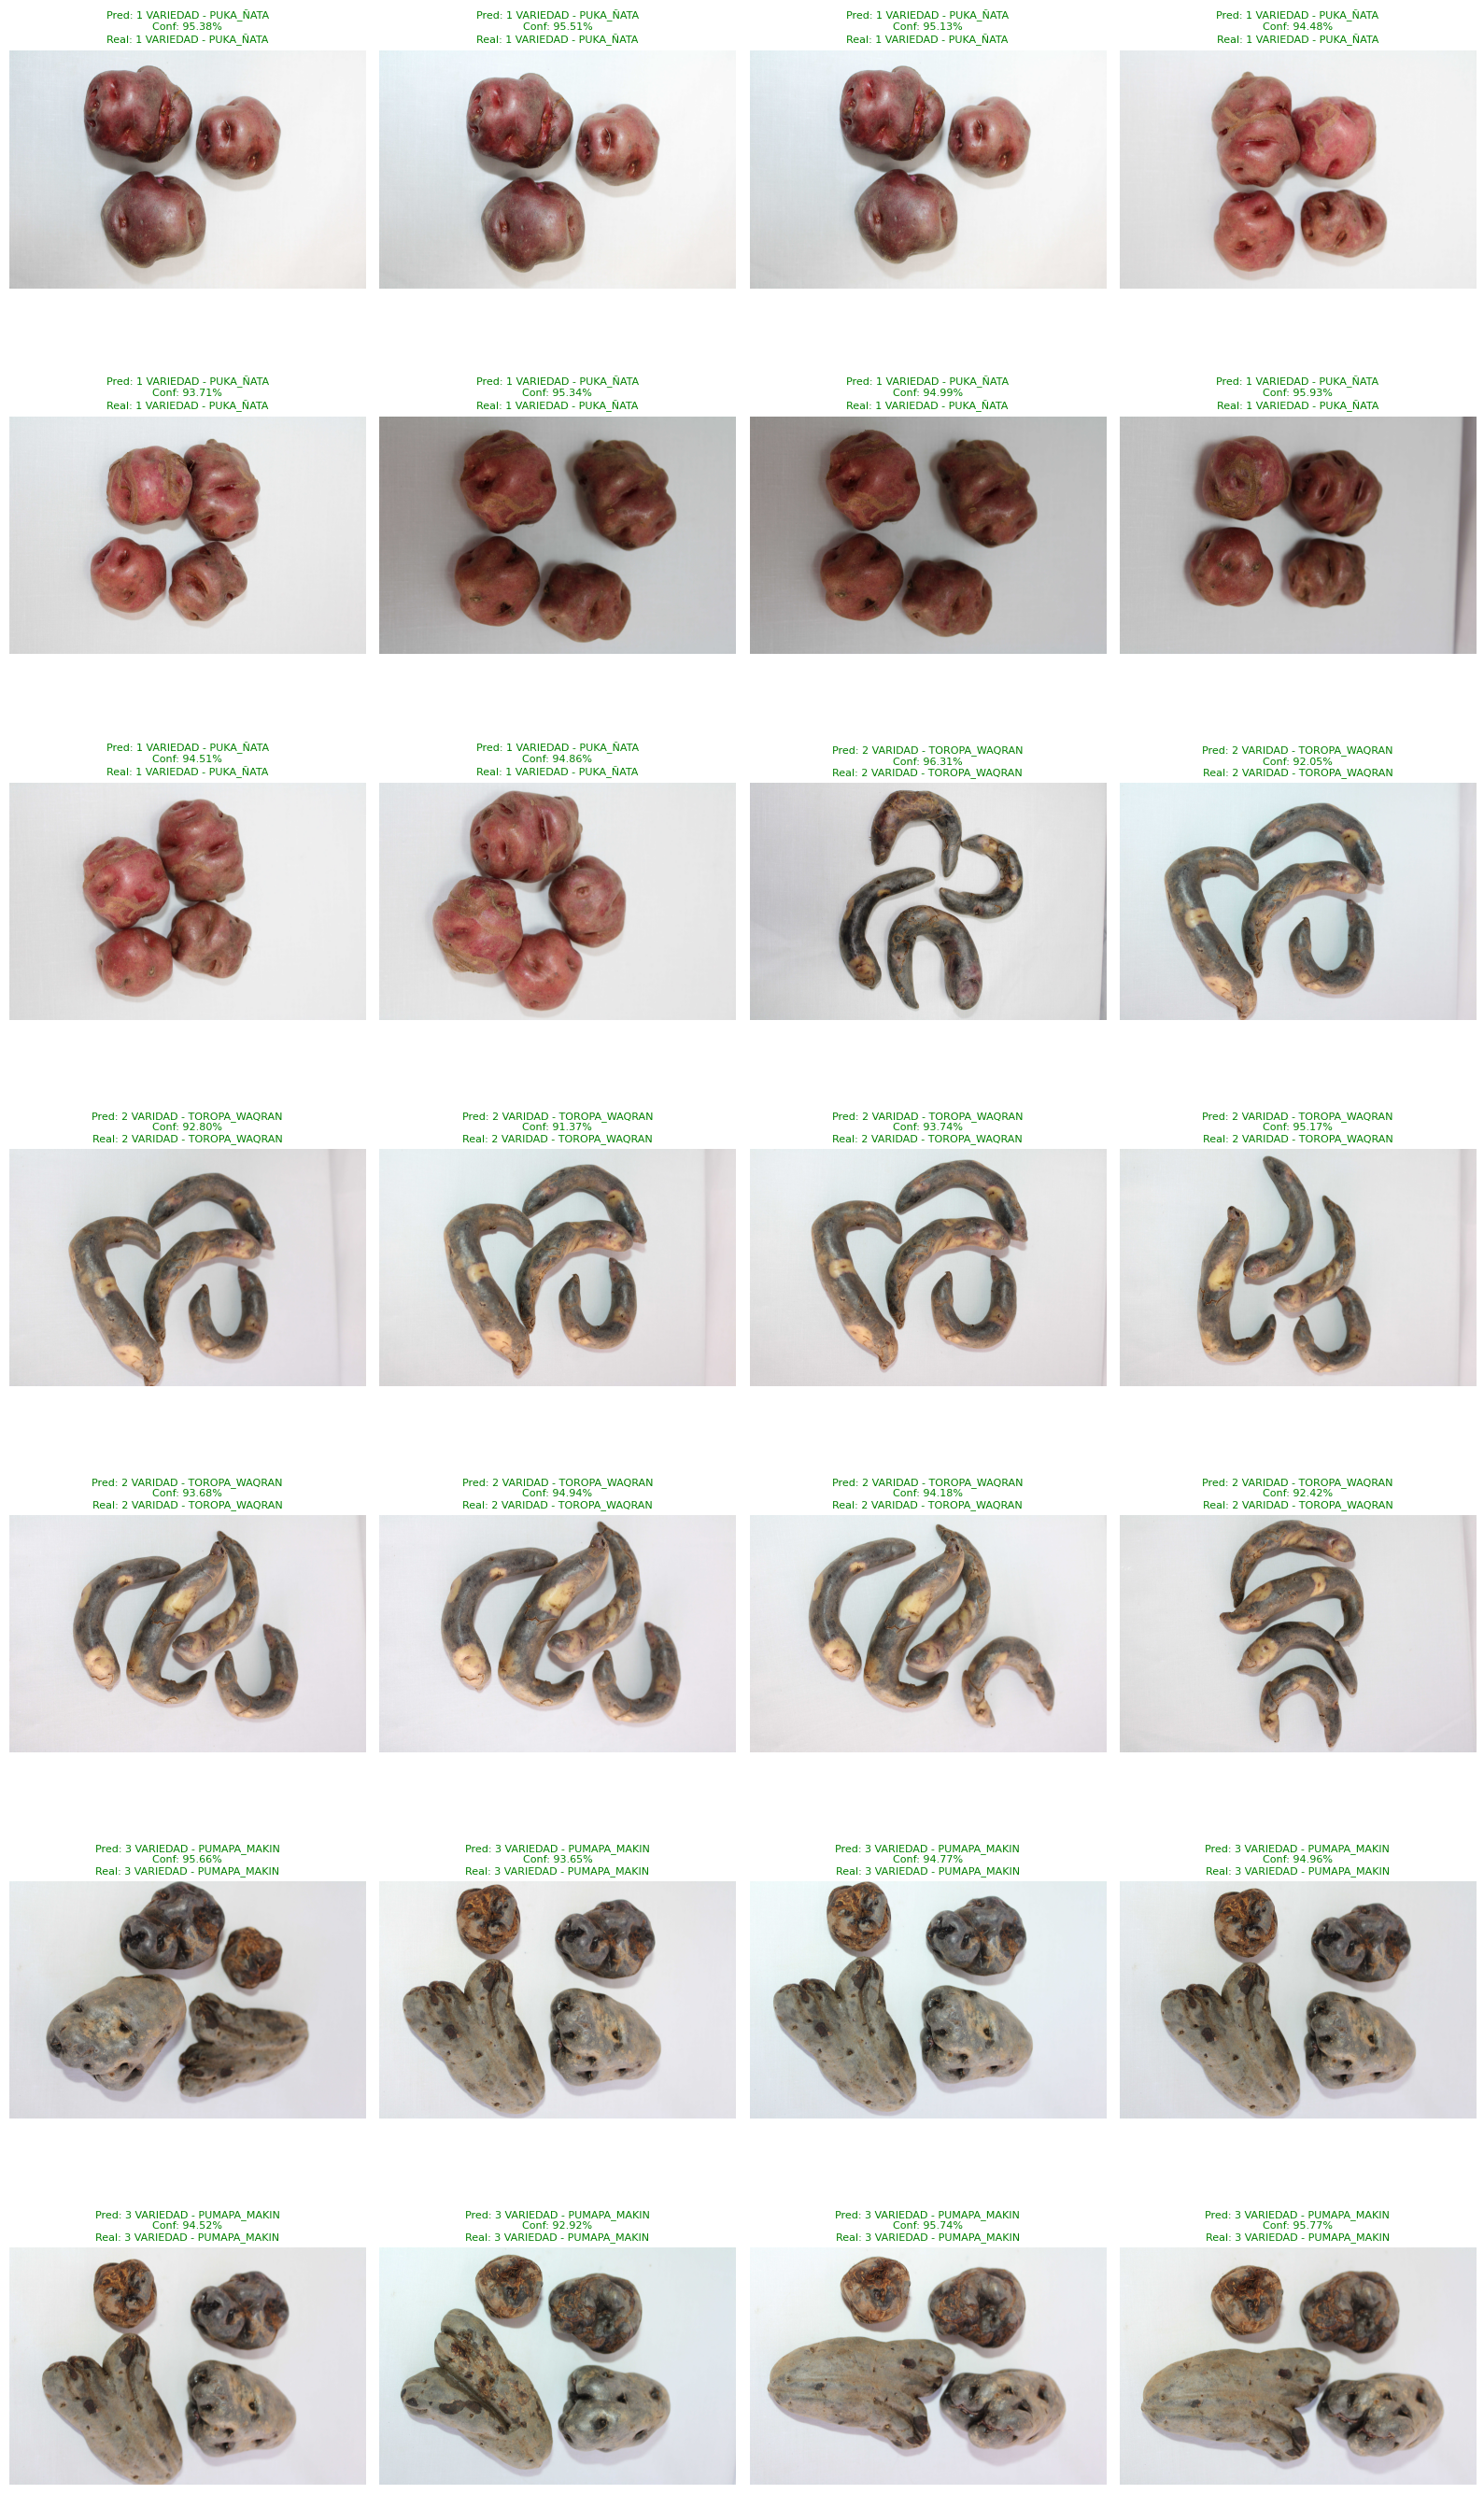

Grid guardado en: /kaggle/working/tomas_training/outputs_swin_dataset_combinado/pruebas_imagenes_reales_swin/grid_predicciones_imagenes_reales_swin.png


In [14]:
# Prueba profesional con imágenes reales propias - Swin
# Esta celda CARGA el checkpoint entrenado desde disco antes de predecir.
TRAINED_SWIN_MODEL_PATH = None  # opcional: Path("/kaggle/input/mi-modelo/swin_tiny_papas_final.pt")
FORCE_RELOAD_TRAINED_MODEL = True
REAL_TEST_IMAGE_DIR = None  # ejemplo: Path("/kaggle/input/mis-papas-reales")
REAL_TEST_IMAGE_PATHS = []  # también puedes pegar rutas individuales aquí
MAX_REAL_TEST_IMAGES = 70
GRID_MAX_IMAGES = 28
CONFIDENCE_WARNING_THRESHOLD = 0.70

REAL_TEST_OUTPUT_DIR = OUTPUT_DIR / "pruebas_imagenes_reales_swin"
REAL_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_existing_checkpoint_path(candidates):
    for candidate in candidates:
        if candidate is None:
            continue
        path = Path(candidate)
        if path.exists():
            return path
    return None


def find_trained_swin_checkpoint_path():
    candidates = []
    if TRAINED_SWIN_MODEL_PATH is not None:
        candidates.append(Path(TRAINED_SWIN_MODEL_PATH))
    for var_name in ["final_model_path", "best_model_path"]:
        if var_name in globals():
            candidates.append(Path(globals()[var_name]))
    candidates.extend([
        MODEL_DIR / "swin_tiny_papas_final.pt",
        MODEL_DIR / "best_model_swin.pt",
    ])
    found = find_existing_checkpoint_path(candidates)
    if found is not None:
        return found

    search_roots = []
    for root_name in ["OUTPUT_DIR", "WORK_ROOT", "MODEL_DIR"]:
        if root_name in globals() and Path(globals()[root_name]).exists():
            search_roots.append(Path(globals()[root_name]))
    if Path("/kaggle/input").exists():
        search_roots.append(Path("/kaggle/input"))
    if Path("/kaggle/working").exists():
        search_roots.append(Path("/kaggle/working"))

    patterns = ["swin_tiny_papas_final.pt", "best_model_swin.pt", "*swin*.pt", "*.pt"]
    discovered = []
    for root in search_roots:
        for pattern in patterns:
            discovered.extend(root.rglob(pattern))
    discovered = sorted(set(discovered), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    if discovered:
        return discovered[0]
    raise FileNotFoundError(
        "No se encontró un checkpoint Swin entrenado (.pt). Ejecuta primero el entrenamiento o define TRAINED_SWIN_MODEL_PATH."
    )


def load_trained_swin_model():
    if "SwinTinyClassifier" not in globals():
        raise RuntimeError("Primero ejecuta la celda donde se define SwinTinyClassifier.")
    path = find_trained_swin_checkpoint_path()
    print(f"Cargando checkpoint Swin entrenado desde: {path}")
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    loaded_model = SwinTinyClassifier(NUM_CLASSES, pretrained=False).to(device)
    loaded_model.load_state_dict(state_dict)
    if GPU_COUNT > 1:
        loaded_model = nn.DataParallel(loaded_model)
    loaded_model.eval()
    print("Checkpoint Swin cargado correctamente.")
    if isinstance(checkpoint, dict) and "class_names" in checkpoint and checkpoint["class_names"] != class_names:
        print("Advertencia: class_names del checkpoint no coincide exactamente con class_names en memoria.")
    return loaded_model, path, checkpoint


if FORCE_RELOAD_TRAINED_MODEL or "model" not in globals():
    model, loaded_swin_model_path, loaded_swin_checkpoint = load_trained_swin_model()
else:
    loaded_swin_model_path = find_trained_swin_checkpoint_path()
    loaded_swin_checkpoint = None
    print(f"Usando modelo Swin ya cargado en memoria. Referencia en disco: {loaded_swin_model_path}")
model.eval()


def is_real_image_path(path):
    text = str(path)
    return Path(path).suffix.lower() in VALID_EXTENSIONS and "__sd_img2img_synthetic_1000" not in text


def infer_label_from_path(path):
    parts_norm = [normalize_key(part) for part in Path(str(path)).parts]
    for idx, class_name in enumerate(class_names):
        if normalize_key(class_name) in parts_norm:
            return idx, class_name
    return None, None


def collect_real_images_for_testing():
    rows = []
    if REAL_TEST_IMAGE_PATHS:
        for p in REAL_TEST_IMAGE_PATHS:
            p = Path(p)
            if p.exists() and is_real_image_path(p):
                label, label_name = infer_label_from_path(p)
                rows.append({"path": str(p), "true_label": label, "true_class": label_name, "source": "manual_paths"})
    elif REAL_TEST_IMAGE_DIR is not None:
        root = Path(REAL_TEST_IMAGE_DIR)
        if not root.exists():
            raise FileNotFoundError(f"No existe REAL_TEST_IMAGE_DIR: {root}")
        for p in sorted(root.rglob("*")):
            if p.is_file() and is_real_image_path(p):
                label, label_name = infer_label_from_path(p)
                rows.append({"path": str(p), "true_label": label, "true_class": label_name, "source": "custom_real_dir"})
    else:
        real_test_df = test_df[~test_df["path"].astype(str).str.contains("__sd_img2img_synthetic_1000", regex=False)].copy()
        if MAX_REAL_TEST_IMAGES is not None:
            per_class = max(1, int(np.ceil(MAX_REAL_TEST_IMAGES / max(NUM_CLASSES, 1))))
            real_test_df = real_test_df.groupby("class_name", group_keys=False).head(per_class).head(MAX_REAL_TEST_IMAGES)
        for _, row in real_test_df.iterrows():
            rows.append({"path": row["path"], "true_label": int(row["label"]), "true_class": row["class_name"], "source": "manifest_test_real"})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No se encontraron imágenes reales para probar. Define REAL_TEST_IMAGE_DIR o REAL_TEST_IMAGE_PATHS.")
    return df.reset_index(drop=True)


@torch.no_grad()
def predict_real_images_swin(real_df):
    model.eval()
    records = []
    for _, row in real_df.iterrows():
        img = Image.open(row["path"]).convert("RGB")
        tensor = eval_transforms(img).unsqueeze(0).to(device)
        with amp_context():
            probs = torch.softmax(model(tensor), dim=1).detach().cpu().numpy()[0]
        top_idx = np.argsort(probs)[::-1][:3]
        pred_label = int(top_idx[0])
        true_label = row.get("true_label", None)
        has_label = true_label is not None and not pd.isna(true_label)
        records.append({
            "path": row["path"],
            "file_name": Path(row["path"]).name,
            "source": row.get("source", "unknown"),
            "model_path": str(loaded_swin_model_path),
            "true_label": true_label,
            "true_class": row.get("true_class", None),
            "pred_label": pred_label,
            "pred_class": class_names[pred_label],
            "confidence_top1": float(probs[pred_label]),
            "top2_class": class_names[int(top_idx[1])],
            "top2_confidence": float(probs[int(top_idx[1])]),
            "top3_class": class_names[int(top_idx[2])],
            "top3_confidence": float(probs[int(top_idx[2])]),
            "is_correct": None if not has_label else bool(pred_label == int(true_label)),
            "low_confidence": bool(float(probs[pred_label]) < CONFIDENCE_WARNING_THRESHOLD),
        })
    return pd.DataFrame(records)


def summarize_real_image_results(results_df, prefix="swin"):
    results_path = REAL_TEST_OUTPUT_DIR / f"resultados_imagenes_reales_{prefix}.csv"
    results_df.to_csv(results_path, index=False, encoding="utf-8")
    labeled = results_df.dropna(subset=["true_label"]).copy()
    summary = {
        "modelo": prefix,
        "loaded_model_path": str(loaded_swin_model_path),
        "n_images": len(results_df),
        "n_labeled": len(labeled),
        "mean_confidence_top1": float(results_df["confidence_top1"].mean()),
        "median_confidence_top1": float(results_df["confidence_top1"].median()),
        "low_confidence_count": int(results_df["low_confidence"].sum()),
    }
    if not labeled.empty:
        y_true_real = labeled["true_label"].astype(int).to_numpy()
        y_pred_real = labeled["pred_label"].astype(int).to_numpy()
        summary.update({
            "accuracy_labeled": float(accuracy_score(y_true_real, y_pred_real)),
            "balanced_accuracy_labeled": float(balanced_accuracy_score(y_true_real, y_pred_real)),
        })
        report_real = pd.DataFrame(classification_report(y_true_real, y_pred_real, labels=list(range(NUM_CLASSES)), target_names=class_names, output_dict=True, zero_division=0)).T
        report_real.to_csv(REAL_TEST_OUTPUT_DIR / f"classification_report_imagenes_reales_{prefix}.csv", encoding="utf-8")
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(REAL_TEST_OUTPUT_DIR / f"resumen_imagenes_reales_{prefix}.csv", index=False, encoding="utf-8")
    print(f"Resultados guardados en: {results_path}")
    display(summary_df)
    display(results_df.sort_values("confidence_top1").head(15))
    return summary_df


def plot_real_image_predictions(results_df, prefix="swin", max_images=GRID_MAX_IMAGES):
    plot_df = results_df.head(max_images).copy()
    cols = 4
    rows = int(np.ceil(len(plot_df) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, (_, row) in enumerate(plot_df.iterrows(), 1):
        img = Image.open(row["path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ok = row.get("is_correct", None)
        color = "black" if pd.isna(ok) else "green" if bool(ok) else "red"
        title = f"Pred: {row['pred_class']}\nConf: {row['confidence_top1']:.2%}"
        if row.get("true_class") is not None and not pd.isna(row.get("true_class")):
            title += f"\nReal: {row['true_class']}"
        ax.set_title(title, color=color, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    out_path = REAL_TEST_OUTPUT_DIR / f"grid_predicciones_imagenes_reales_{prefix}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grid guardado en: {out_path}")

real_images_df = collect_real_images_for_testing()
real_results_swin = predict_real_images_swin(real_images_df)
real_summary_swin = summarize_real_image_results(real_results_swin, "swin")
plot_real_image_predictions(real_results_swin, "swin")